#  Plots Summaries for Variables Across European Cities

This notebook provides a comprehensive visual analysis of key variables across various European cities.

The primary objective of this section is to generate and present **clear, comparative plots** for each significant variable in the dataset. These visualizations allow for a quick and intuitive understanding of the **distribution, range, and comparative performance** of the variable values among all included cities in Europe.



## Load libraries

Here we load the required libraries to execute the notebook. Note that specific code from dedicated scripts (`utils.py`, `urban_areas.py`, ...) is also loaded here.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
!echo $CONDA_DEFAULT_ENV

jsc


In [3]:
# =============================================================================
# 1. STANDARD LIBRARY IMPORTS
# =============================================================================
import calendar
import glob
import itertools
import math
import os
import random
import re
import sys
import unicodedata
from difflib import SequenceMatcher
from math import asin, cos, radians, sin, sqrt
from pathlib import Path

# =============================================================================
# 2. THIRD-PARTY LIBRARY IMPORTS
# =============================================================================
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cf_xarray
import cordex as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyproj
import regionmask
import seaborn as sns
import unidecode
import xarray as xr
import xesmf as xe
import yaml
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon, Wedge
from shapely import contains_xy, vectorized
from shapely.geometry import Point

# =============================================================================
# 3. LOCAL / INTERNAL MODULES
# =============================================================================
from evaltools.source import xarray_open_kwargs
from tools import (
    check_equal_period,
    fix_360_longitudes,
    open_datasets,
    standardize_unit,
)
from urclimask.GHCNd_stations import get_valid_timeseries, inside_city
from urclimask.UHI_analysis import UrbanIsland
from urclimask.urban_areas import UrbanVicinity, plot_urban_polygon
from urclimask.utils import load_ucdb_city, traverseDir

In [4]:
save_results_path = os.path.abspath(
    os.path.join(os.getcwd(), "..", "intermediate-results")
)
save_figure_path = os.path.abspath(os.path.join(os.getcwd(), "..", "plots"))
save_figure_dataset = os.path.abspath(os.path.join(os.getcwd(), "..", "datasets"))
save_summary_path = os.path.join(save_figure_path, "summaries")
os.makedirs(save_summary_path, exist_ok=True)

In [5]:
city = "Paris" 
variable = "tasmax"  
period = slice(1991, 2020)
rcm_names = [
    'ALARO1-SFX_v1-r1',
    'CNRM-ALADIN64E1_v1-r1',
    'CCLM6-0-1-URB_v1-r1', 
    'CCLM6-0-1-URB-ESG_v1-r1', 
    'HCLIM43-ALADIN_v1-r1',
    'ICON-CLM-202407-1-1_v1-r1',
    'RACMO23E_v1-r1', 
    'RegCM5-0_v1-r1',
    #'REMO2020-2-2-MR2_v1-r1',
    'REMO2020-2-2-TEB_v1-r1',
    'REMO2020-2-2_v1-r1', 
    'REMO2020-2-2-iMOVE_v1-r1', 
    'ROAM-NBS_v1-r1',
    'WRF451Q_v1-r1',
    #'WRF451Q_v1-r2',
    #'HadREM3-GA7-01_v1-r1'
    'HadREM3-GA7-05_v1-r1'
]


In [6]:
def clean_color(c):
    if pd.isna(c):
        return None
    s = str(c).strip()
    if not s:
        return None
    return s if s.startswith("#") else "#" + s
def has_ucm_suffix(rcm_name):
    """
    Returns True if model name explicitly contains an urban canopy model.
    """
    return any(f"-{suffix}_" in rcm_name or rcm_name.endswith(f"-{suffix}")
               for suffix in UCM_SUFFIXES)


# =============================================================================
# Extract base model name
# =============================================================================
def get_base_model_name(rcm_name):

    name = re.split(r"_v\d", rcm_name)[0]

    name = re.sub(r"-(TEB|SLUCM|BEP|BEM|UCM)$", "", name)

    return name

def clean_string(s):
    if isinstance(s, str):
        return s.strip().replace("\ufeff", "")
    return s

## Annual cycle

In [ ]:
csv_path = "eurocordex_models_urban.csv"
models_df = pd.read_csv(csv_path, sep=",", engine="python", dtype=str)
models_df.columns = [c.strip() for c in models_df.columns]

required_cols = {"model", "mip_era", "color", "urban"}
if not required_cols.issubset(set(models_df.columns)):
    raise RuntimeError(
        f"Missing columns in {csv_path}. Required: {required_cols}. "
        f"Found: {models_df.columns.tolist()}"
    )

models_cmip6 = models_df[models_df["mip_era"].str.strip() == "CMIP6"].copy()
models_cmip6["color"] = models_cmip6["color"].apply(clean_color)

##### Detect UCM suffix directly from model name


In [ ]:
UCM_SUFFIXES = ("TEB", "SLUCM", "BEP", "BEM", "UCM" )
rcm_base_names = [get_base_model_name(name) for name in rcm_names]
models_plot = models_cmip6[models_cmip6["model"].isin(rcm_base_names)].copy()

##### Create mapping dicts


In [7]:
model_colors = {}
model_styles = {}

for rcm_name in rcm_names:
    base = get_base_model_name(rcm_name)
    row = models_plot.loc[models_plot["model"] == base]

    # assign color
    if not row.empty:
        color = row["color"].values[0]
        model_colors[rcm_name] = color if pd.notna(color) else "#999999"
    else:
        model_colors[rcm_name] = "#999999"

    # detect UCM from model name
    if has_ucm_suffix(rcm_name):

        model_styles[rcm_name] = {
            "linestyle": "--",
            "marker": "o"
        }
    # fallback to CSV urban column
    elif not row.empty and row["urban"].values[0].strip() == "UCM":

        model_styles[rcm_name] = {
            "linestyle": "--",
            "marker": "o"
        }

    # Default
    else:

        model_styles[rcm_name] = {
            "linestyle": "-",
            "marker": None
        }


In [8]:
def plot_urban_annual_cycle_city(
    city,
    rcm_names,
    variable,
    period,
    save_figure_dataset,
    save_figure_path,
    model_colors,
    model_styles
):
    """
    Plot the urban annual cycle for a given city and variable using CMIP6 RCM outputs
    and observational data.

    Parameters
    ----------
    city : str
        City name.
    rcm_names : list of str
        List of RCM identifiers.
    variable : str
        Variable name to plot.
    period : object
        Period object with attributes 'start' and 'stop'.
    save_figure_dataset : str
        Base path where NetCDF and CSV files are stored.
    save_figure_path : str
        Base path where figures will be saved.
    model_colors : dict
        Dictionary mapping RCM names to colors.
    model_styles : dict
        Dictionary mapping RCM names to style options
        (e.g., {'model': {'linestyle': '--', 'marker': 'o'}}).
    """
    # -------------------------------------------------------------------------
    # Create output directory
    # -------------------------------------------------------------------------
    save_summary_path = os.path.join(save_figure_path, "summaries")
    os.makedirs(save_summary_path, exist_ok=True)

    # -------------------------------------------------------------------------
    # Plot initialization
    # -------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(15, 7))

    # -------------------------------------------------------------------------
    # Loop over RCMs
    # -------------------------------------------------------------------------
    for rcm_name in rcm_names:

        output_nc_path = (
            f"{save_figure_dataset}/Annual_cycle/"
            f"CMIP6_{city}_Annual_cycle_{variable}_{rcm_name}_"
            f"{period.start}-{period.stop}.nc"
        )

        output_urmask_nc_path = (
            f"{save_figure_dataset}/urmask/"
            f"CMIP6_{city}_urmask_{rcm_name}.nc"
        )

        if not os.path.exists(output_nc_path):
            print(f"Skipping {rcm_name}: missing NetCDF file.")
            continue

        try:
            ds_anomaly = xr.open_dataset(output_nc_path)[variable]
            urmask = xr.open_dataset(output_urmask_nc_path)

            # -----------------------------------------------------------------
            # Align coordinates
            # -----------------------------------------------------------------
            ds_anomaly = ds_anomaly.assign_coords(
                {
                    urmask.cf['X'].name: urmask[urmask.cf['X'].name],
                    urmask.cf['Y'].name: urmask[urmask.cf['Y'].name],
                }
            )

            # -----------------------------------------------------------------
            # Apply urban mask
            # -----------------------------------------------------------------
            is_urban = urmask["urmask"] == 1
            urban_anomaly = ds_anomaly.where(is_urban)

            # -----------------------------------------------------------------
            # Spatial mean over urban grid cells
            # -----------------------------------------------------------------
            urban_mean = urban_anomaly.mean(
                dim=[ds_anomaly.cf['Y'].name, ds_anomaly.cf['X'].name]
            ).compute()

            # -----------------------------------------------------------------
            # Retrieve style information
            # -----------------------------------------------------------------
            style = model_styles.get(rcm_name, {})
            linestyle = style.get("linestyle", "-")
            marker = style.get("marker", None)

            # -----------------------------------------------------------------
            # Plot model line
            # -----------------------------------------------------------------
            urban_mean.plot(
                ax=ax,
                color=model_colors.get(rcm_name, "#999999"),
                linewidth=3,
                linestyle=linestyle,
                label=rcm_name
            )

        except Exception as e:
            print(f"Error processing {rcm_name}: {e}")
            continue

    # -------------------------------------------------------------------------
    # Observations
    # -------------------------------------------------------------------------
    output_obs_csv_path = (
        f"{save_figure_dataset}/Annual_cycle/observations/"
        f"CMIP6_{city}_Annual_cycle_{variable}_OBS_"
        f"{period.start}-{period.stop}.csv"
    )

    if os.path.exists(output_obs_csv_path):

        obs_df = pd.read_csv(output_obs_csv_path)

        if obs_df.index[0] == 0:
            obs_df.index += 1

        ax.plot(
            obs_df.index,
            obs_df["urban_mean"],
            color="black",
            linestyle="--",
            marker="o",
            linewidth=4,
            label="Obs.",
            zorder=2000
        )

    else:
        print(f"Observation file not found: {output_obs_csv_path}")

    # -------------------------------------------------------------------------
    # Axis configuration
    # -------------------------------------------------------------------------
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(range(1, 13), fontsize=14)
    ax.set_xlim(1, 12)
    ax.set_xlabel("Month") 

    # Fixed y-axis range
    ax.set_ylim(-2, 4)

    # -------------------------------------------------------------------------
    # Axis labels
    # -------------------------------------------------------------------------
    if variable in ["tasmin", "tasmax"]:
        ylabel = f"{variable} (°C)"
    else:
        ylabel = variable

    ax.set_ylabel(ylabel, fontsize=14)

    # -------------------------------------------------------------------------
    # Title
    # -------------------------------------------------------------------------
    ax.set_title("")  
    # -------------------------------------------------------------------------
    # Legend outside the figure
    # -------------------------------------------------------------------------
    ax.legend(
        fontsize=13,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )

    ax.grid(True)

    # -------------------------------------------------------------------------
    # Layout adjustment (space for legend)
    # -------------------------------------------------------------------------
    plt.tight_layout(rect=[0, 0, 0.82, 1])

    # -------------------------------------------------------------------------
    # Save figure
    # -------------------------------------------------------------------------
    output_png_path = os.path.join(
        save_summary_path,
        f"CMIP6_{city}_Annual_cycle_{variable}_{period.start}-{period.stop}.png"
    )

    plt.savefig(output_png_path, dpi=300)
    output_pdf_path = os.path.join(
        save_summary_path,
        f"CMIP6_{city}_Annual_cycle_{variable}_{period.start}-{period.stop}.pdf"
    )
    plt.savefig(output_pdf_path) 
    print(f"Figure saved to: {output_png_path}")

Figure saved to: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Paris_Annual_cycle_tasmin_1991-2020.png


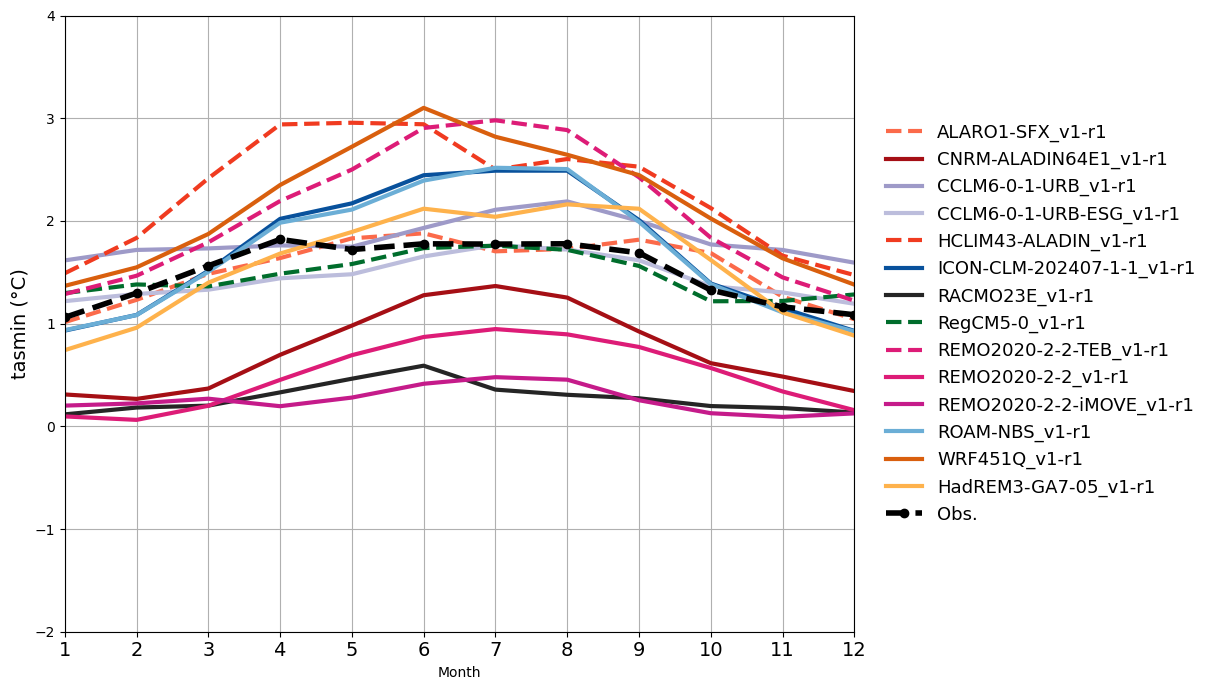

In [9]:
plot_urban_annual_cycle_city(
     city=city,
     rcm_names=rcm_names,
     variable='tasmin',
     period=period,
     save_figure_dataset=save_figure_dataset,
     save_figure_path=save_figure_path,
     model_colors=model_colors,
     model_styles=model_styles
)

In [10]:
# Cargar el archivo YAML
with open("cities.yaml", "r") as f:
    cities = yaml.safe_load(f)

In [11]:
def plot_urban_annual_cycle_all_cities(
    cities,
    rcm_names,
    variable,
    period,
    save_figure_dataset,
    save_figure_path,
    model_colors,
    model_styles,
    obs_color="k",
):
    """
    Plot urban annual cycles for multiple cities in a multi-panel layout.

    Parameters
    ----------
    cities : list of str
        List of city names (excluding or including 'default').
    rcm_names : list of str
        List of RCM identifiers.
    variable : str
        Variable name to plot.
    period : object
        Period object with attributes 'start' and 'stop'.
    save_figure_dataset : str
        Base path where NetCDF and CSV files are stored.
    save_figure_path : str
        Base path where figures will be saved.
    model_colors : dict
        Dictionary mapping RCM names to colors.
    model_styles : dict
        Dictionary mapping RCM names to line styles.
    obs_color : str, optional
        Color used for observations (default: black).
    """
    # -------------------------------------------------------------------------
    # Output directory
    # -------------------------------------------------------------------------
    save_summary_path = os.path.join(save_figure_path, "summaries")
    os.makedirs(save_summary_path, exist_ok=True)

    # -------------------------------------------------------------------------
    # Layout
    # -------------------------------------------------------------------------
    ncols = 2
    valid_cities = [c for c in cities if c != "default"]
    nplots = len(valid_cities)
    nrows = math.ceil(nplots / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.3 * ncols, 3.8 * nrows),
        sharex=True
    )

    axes = axes.flatten()

    # -------------------------------------------------------------------------
    # Nice model names
    # -------------------------------------------------------------------------
    model_labels = {
        "HadREM3-GA7-05": "HadREM3",
        "REMO2015": "REMO",
        "RegCM5": "RegCM5",
        "WRF381P": "WRF",
    }

    # -------------------------------------------------------------------------
    # Main loop over cities
    # -------------------------------------------------------------------------
    plot_idx = 0
    for city in valid_cities:
        ax = axes[plot_idx]
        plot_idx += 1
        plotted_any = False

        # ---------------------------------------------------------------------
        # Loop over RCMs
        # ---------------------------------------------------------------------
        for rcm_name in rcm_names:
            output_nc_path = (
                f"{save_figure_dataset}/Annual_cycle/"
                f"CMIP6_{city}_Annual_cycle_{variable}_{rcm_name}_"
                f"{period.start}-{period.stop}.nc"
            )

            output_urmask_nc_path = (
                f"{save_figure_dataset}/urmask/"
                f"CMIP6_{city}_urmask_{rcm_name}.nc"
            )

            if not (os.path.exists(output_nc_path) and os.path.exists(output_urmask_nc_path)):
                continue

            try:
                ds_anomaly = xr.open_dataset(output_nc_path)[variable]
                urmask = xr.open_dataset(output_urmask_nc_path)

                ds_anomaly = ds_anomaly.assign_coords({
                    urmask.cf['X'].name: urmask[urmask.cf['X'].name],
                    urmask.cf['Y'].name: urmask[urmask.cf['Y'].name]
                })

                is_urban = urmask["urmask"] == 1
                urban_anomaly = ds_anomaly.where(is_urban)

                urban_mean = urban_anomaly.mean(
                    dim=[ds_anomaly.cf['Y'].name, ds_anomaly.cf['X'].name]
                ).compute()

                urban_mean.plot(
                    ax=ax,
                    color=model_colors.get(rcm_name, "#999999"),
                    linestyle=model_styles[rcm_name]["linestyle"],
                    linewidth=2.5,
                    label=model_labels.get(rcm_name, rcm_name)  # <-- Nice name
                )

                plotted_any = True

            except Exception as e:
                print(f"Error in {city} - {rcm_name}: {e}")
                continue

        # ---------------------------------------------------------------------
        # Observations
        # ---------------------------------------------------------------------
        output_obs_csv_path = (
            f"{save_figure_dataset}/Annual_cycle/observations/"
            f"CMIP6_{city}_Annual_cycle_{variable}_OBS_"
            f"{period.start}-{period.stop}.csv"
        )

        if os.path.exists(output_obs_csv_path):
            obs_df = pd.read_csv(output_obs_csv_path)

            if "month" in obs_df.columns:
                obs_df.set_index("month", inplace=True)
            elif obs_df.index[0] == 0:
                obs_df.index += 1

            if "urban_mean" in obs_df.columns:
                ax.plot(
                    obs_df.index,
                    obs_df["urban_mean"],
                    color=obs_color,
                    linestyle=":",
                    marker="o",
                    linewidth=3,
                    label="Obs.",
                    zorder=2000
                )
                plotted_any = True
            else:
                print(f"Missing 'urban_mean' column in {output_obs_csv_path}")
        else:
            print(f"Missing observation file for {city}")

        # ---------------------------------------------------------------------
        # Formatting
        # ---------------------------------------------------------------------
        ax.set_title("", fontsize=16, pad=10)
        
        ax.text(
            0.5, 0.98, city,
            transform=ax.transAxes,
            fontsize=20,
            ha="center",
            va="top"
        )

        ax.grid(True, alpha=0.3)
        ax.set_xticks(range(1, 13))
        ax.set_xlim(1, 12)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(
            [calendar.month_abbr[m][0] for m in range(1, 13)],
            fontsize=15
        )

        if variable == "hurs":
            ax.set_ylim(-15, 10)
        elif variable == "sfcWind":
            ax.set_ylim(-2, 2)
        elif variable == "tasmin":
            ax.set_ylim(-1, 5)
        elif variable == "tasmax":
            ax.set_ylim(-2, 3)

        ax.tick_params(axis="both", which="major", labelsize=16)

        # Hide y-axis labels except first column
        if plot_idx % ncols != 1:
            ax.set_yticklabels([])

        if not plotted_any:
            ax.set_facecolor("#f5f5f5")

    # -------------------------------------------------------------------------
    # Remove unused axes
    # -------------------------------------------------------------------------
    for j in range(plot_idx, len(axes)):
        fig.delaxes(axes[j])

    # -------------------------------------------------------------------------
    # Legend
    # -------------------------------------------------------------------------
    handles, labels = [], []
    for ax in axes[:plot_idx]:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    unique = dict(zip(labels, handles))
    handles, labels = list(unique.values()), list(unique.keys())

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=4,
        fontsize=18,
        bbox_to_anchor=(0.5, 0.98)  # <-- slightly higher
    )

    # -------------------------------------------------------------------------
    # Title and save
    # -------------------------------------------------------------------------
    units = {
        "tasmin": "K",
        "tasmax": "K",
        "pr": "% (mm/day)",
        "sfcWind": "m/s",
        "hurs": "%"
    }.get(variable, "")

    fig.suptitle(f"{variable} ({units})", fontsize=20, y=0.9)

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)

    output_png = os.path.join(
        save_summary_path,
        f"CMIP6_AllCities_{variable}_{period.start}-{period.stop}.png"
    )
    plt.savefig(output_png, dpi=300, bbox_inches="tight")
    print(f"Figure saved to: {output_png}")

    output_pdf = os.path.join(
        save_summary_path,
        f"CMIP6_AllCities_{variable}_{period.start}-{period.stop}.pdf"
    )
    plt.savefig(output_pdf, format="pdf", bbox_inches="tight")
    print(f"Figure saved to: {output_pdf}")

Missing observation file for Athens
Missing observation file for Birmingham
Missing observation file for Copenhagen
Missing observation file for Glasgow
Missing observation file for London
Missing observation file for Riga
Missing observation file for Stockholm
Figure saved to: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_AllCities_hurs_1991-2020.png
Figure saved to: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_AllCities_hurs_1991-2020.pdf


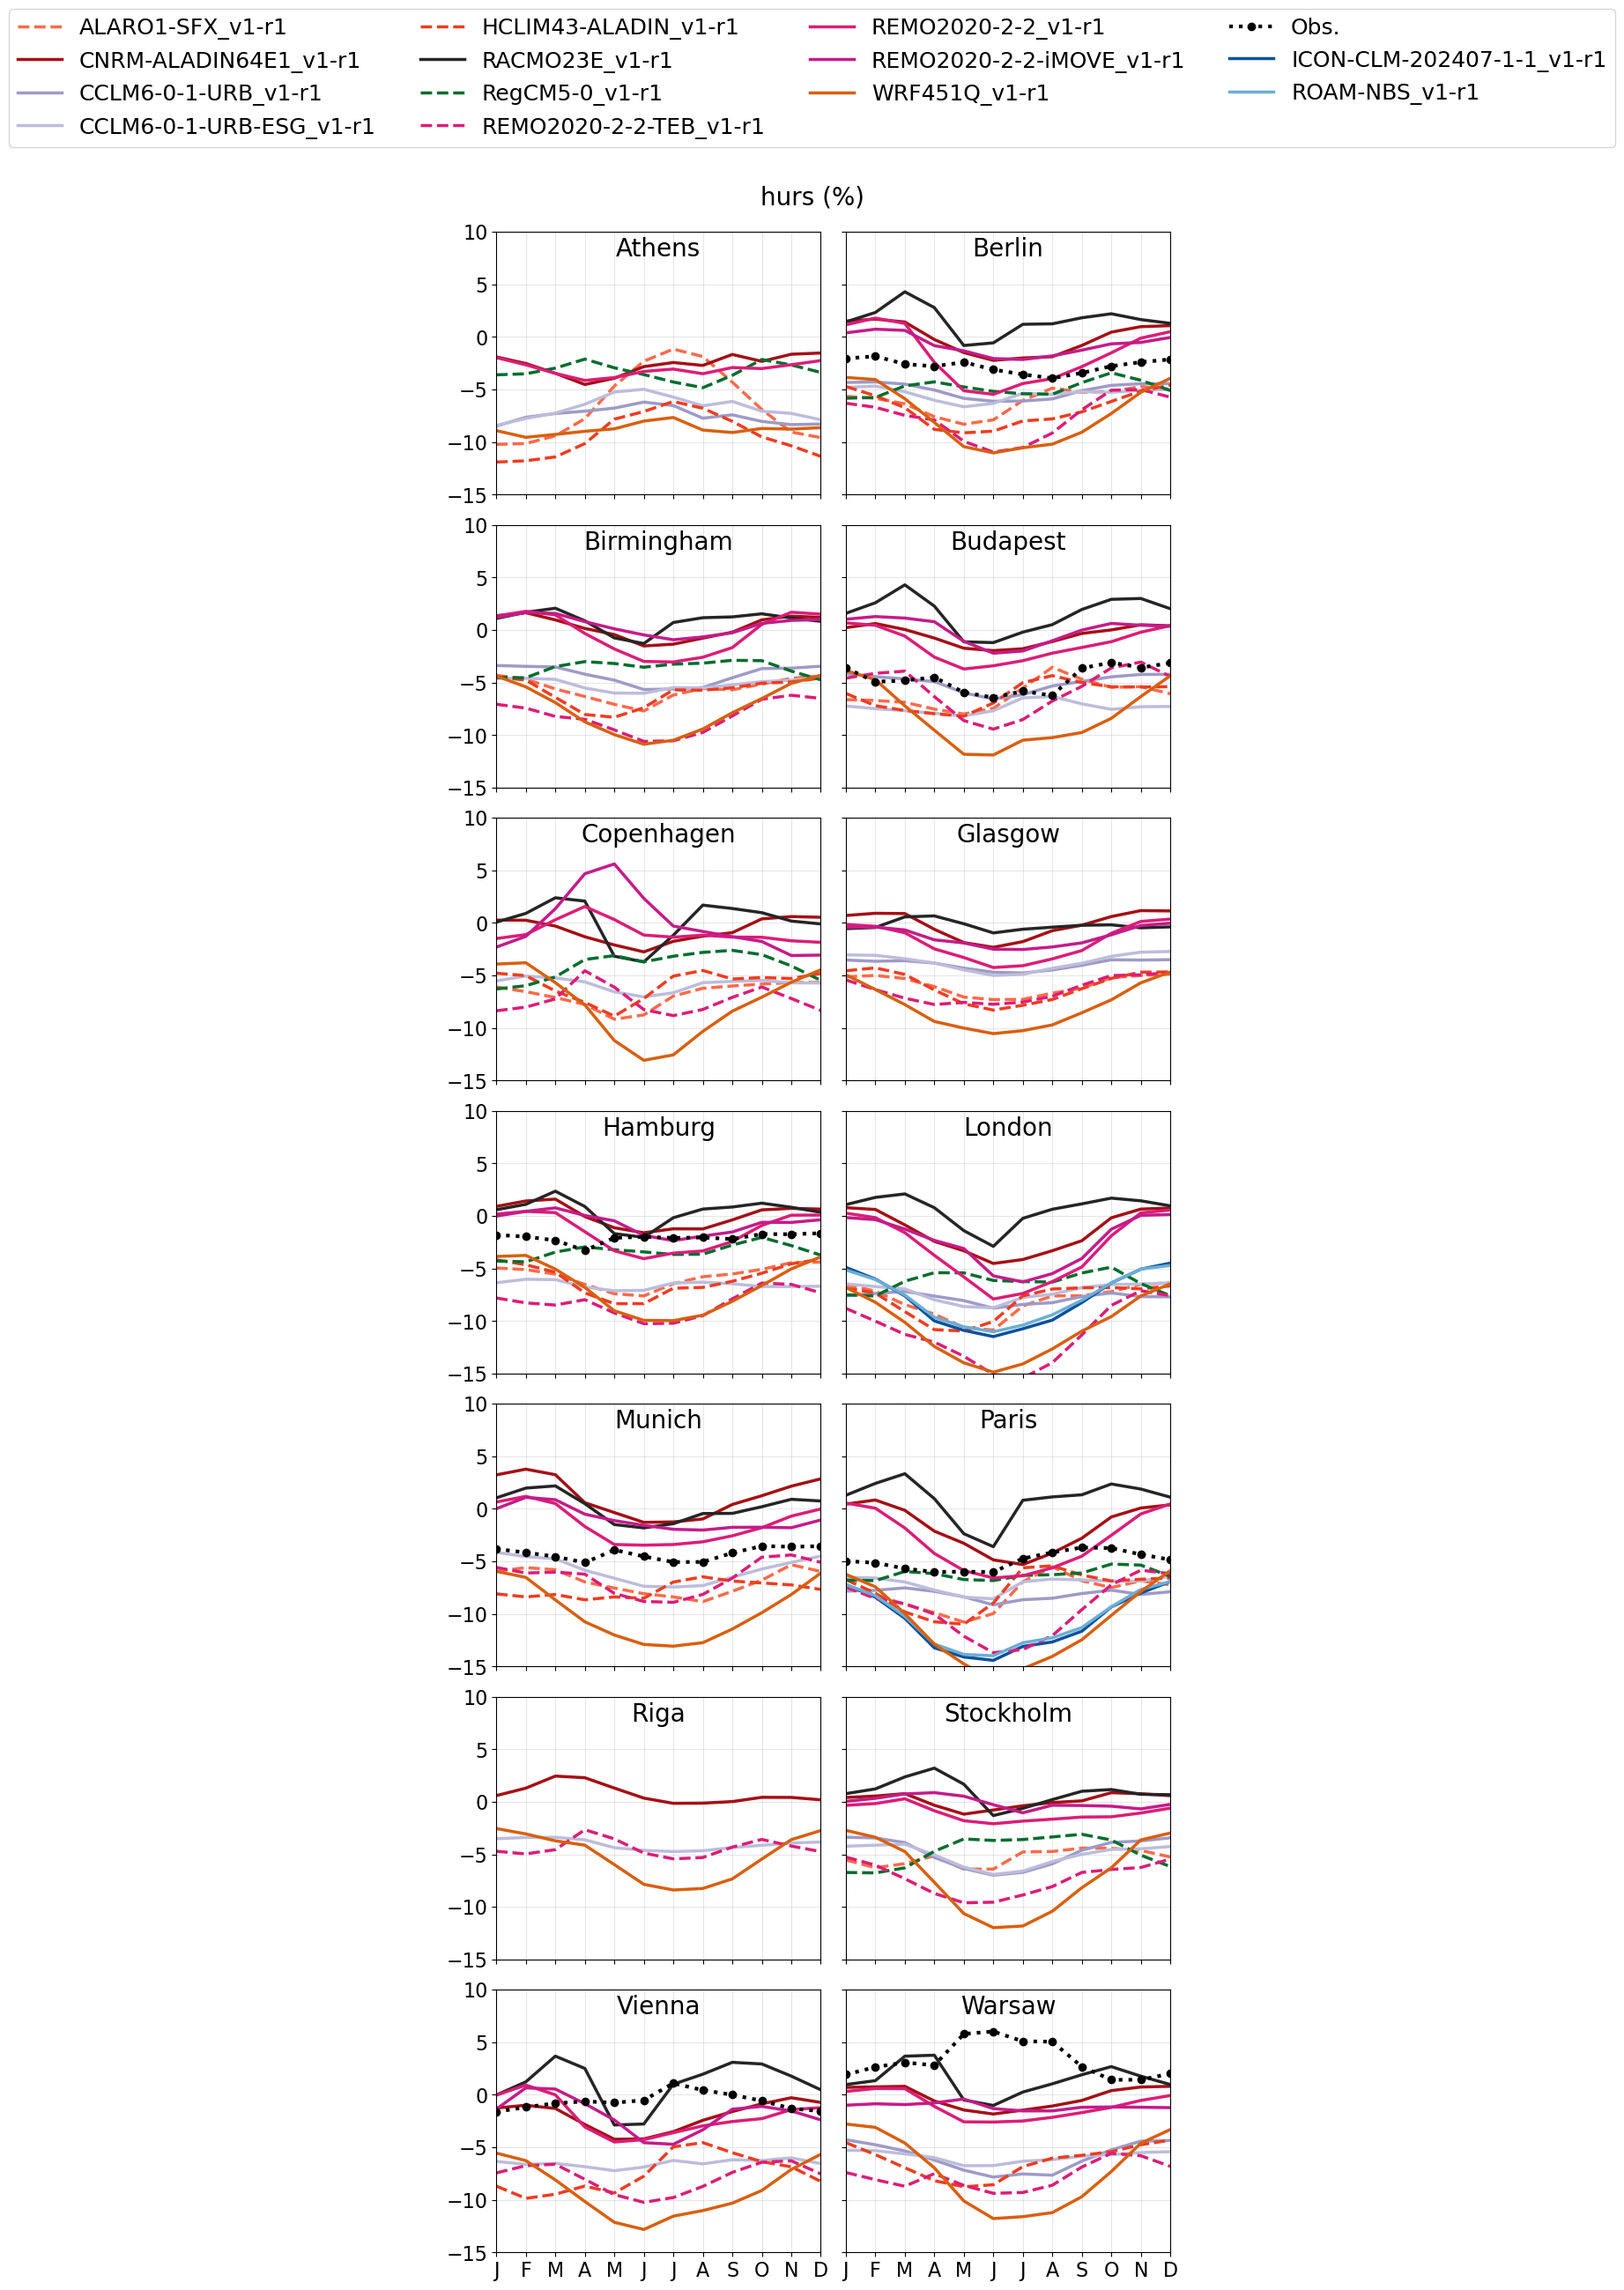

In [12]:
plot_urban_annual_cycle_all_cities(
    cities=cities,
    rcm_names=rcm_names,
    variable=variable,
    period=period,
    save_figure_dataset=save_figure_dataset,
    save_figure_path=save_figure_path,
    model_colors=model_colors,
    model_styles=model_styles
)


## Heatmap

In [13]:
root_aux_data = "/mnt/CORDEX_CMIP6_tmp/aux_data/"
ucdb_path = f"{root_aux_data}GHS_FUA_UCD/GHS_UCDB_GLOBE_R2024A.gpkg"

# Load UCDB layers
gdf_centroids = gpd.read_file(ucdb_path, layer="UC_centroids")
gdf_char = gpd.read_file(ucdb_path, layer="GHS_UCDB_THEME_GENERAL_CHARACTERISTICS_GLOBE_R2024A")

# Clean column names
gdf_centroids.columns = gdf_centroids.columns.str.strip().str.replace("﻿", "", regex=True)
gdf_char.columns = gdf_char.columns.str.strip().str.replace("﻿", "", regex=True)

# Reproject to WGS84
gdf_centroids = gdf_centroids.to_crs(epsg=4326)

# Merge centroid geometry with characteristics
gdf_merged = gdf_char.merge(
    gdf_centroids[["ID_UC_G0", "geometry"]],
    on="ID_UC_G0",
    suffixes=("_char", "_centroid")
)

# Set the geometry to the centroid geometry
gdf_merged = gdf_merged.set_geometry("geometry_centroid")

# Extract lon/lat for filtering
lon_tmp = gdf_merged.geometry.x
lat_tmp = gdf_merged.geometry.y

# Filter cities by area and Europe bounding box
gdf_filtered = gdf_merged[gdf_merged["GC_UCA_KM2_2025"] >= 12.12 * 12.12].copy()
gdf_europe = gdf_filtered[
    (lat_tmp >= 34) & (lat_tmp <= 72) &
    (lon_tmp >= -25) & (lon_tmp <= 45)
].copy()

print(f"Filtered European cities (≥144 km²): {len(gdf_europe)}")


# ----------------------------------------------------------------------
# PREPARE CITY-COUNTRY LIST
# ----------------------------------------------------------------------
gdf_europe["GC_UCN_MAI_2025"] = gdf_europe["GC_UCN_MAI_2025"].apply(clean_string)
gdf_europe["GC_CNT_GAD_2025"] = gdf_europe["GC_CNT_GAD_2025"].apply(clean_string)
city_country_list = list(zip(gdf_europe["GC_UCN_MAI_2025"], gdf_europe["GC_CNT_GAD_2025"]))

Filtered European cities (≥144 km²): 105


/home/yquintana/.conda/envs/jsc/lib/python3.10/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


In [14]:
# SORT CITIES BY URBAN AREA AND CAPITALIZE NAMES
# Sort by area (descending: largest first)
gdf_sorted = gdf_europe.sort_values(by="GC_UCA_KM2_2025", ascending=False).reset_index(drop=True)

# Capitalize city names
gdf_sorted["GC_UCN_MAI_2025"] = gdf_sorted["GC_UCN_MAI_2025"].str.title()  # "essen" -> "Essen"

# Create ordered city and country lists
cities = gdf_sorted["GC_UCN_MAI_2025"].tolist()
countries = gdf_sorted["GC_CNT_GAD_2025"].tolist()

city_country_list = list(zip(cities, countries))

print(f"European cities sorted by area: {len(cities)} total")
print("Top 10 largest cities by area:")
print(gdf_sorted[["GC_UCN_MAI_2025", "GC_UCA_KM2_2025"]].head(10))

European cities sorted by area: 105 total
Top 10 largest cities by area:
  GC_UCN_MAI_2025  GC_UCA_KM2_2025
0          London             1649
1          Moscow             1545
2           Paris             1421
3        Istanbul             1269
4           Essen              880
5           Milan              785
6      Manchester              751
7      Birmingham              685
8          Berlin              681
9          Madrid              680


In [15]:
# 1. Create a helper mapping from your rcm_names list
rcm_mapping = pd.DataFrame({
    'full_name': rcm_names,
    'model_base': [name.split('_')[0] for name in rcm_names]
})

# 2. Merge with your df_model to get the 'urban' attribute
sort_df = rcm_mapping.merge(models_df[['model', 'urban']], 
                            left_on='model_base', 
                            right_on='model', 
                            how='left')

# 3. Define the Priority: UCM = 0, others = 1
sort_df['priority'] = np.where(sort_df['urban'] == 'UCM', 0, 1)

# 4. Sort by priority (UCM first) and then by the full name (Alphabetical)
sort_df = sort_df.sort_values(by=['priority', 'full_name'])

# 5. Extract the final ordered list
ordered_rcm_names = sort_df['full_name'].tolist()
ordered_rcm_names = list(dict.fromkeys(ordered_rcm_names))

In [16]:
def plot_cmip6_seasonal_heatmap(
    cities,
    rcm_names,
    variable,
    period,
    save_figure_dataset,
    save_figure_path
):
    """
    Plot a split-triangle heatmap of mean seasonal (JJA / DJF) urban anomalies.
    The labels are cleaned to remove everything after the first '_'.
    """
    # -------------------------------------------------------------------------
    # Remove HadREM for variables without wind/humidity support
    # -------------------------------------------------------------------------
    if variable in ["sfcWind", "hurs"]:
        rcm_names = [r for r in rcm_names if "HadREM" not in r]

    # -------------------------------------------------------------------------
    # Colormap and limits
    # -------------------------------------------------------------------------
    if variable in ["tasmin", "tasmax"]:
        colormap = plt.cm.bwr
        vmin, vmax = -5, 5
    elif variable == "sfcWind":
        colormap = plt.cm.PiYG
        vmin, vmax = -1.5, 1.5
    else:
        colormap = plt.cm.BrBG
        vmin, vmax = -15, 15

    valid_cities = [c for c in cities if c.lower() != "default"]
    save_summary_path = os.path.join(save_figure_path, "summaries")
    os.makedirs(save_summary_path, exist_ok=True)

    nrows = len(valid_cities)
    ncols = len(rcm_names)

    summer_means = np.full((nrows, ncols), np.nan)
    winter_means = np.full((nrows, ncols), np.nan)

    # -------------------------------------------------------------------------
    # Data extraction
    # -------------------------------------------------------------------------
    for i, city in enumerate(valid_cities):
        for j, rcm_name in enumerate(rcm_names):

            nc_path = (
                f"{save_figure_dataset}/Annual_cycle/"
                f"CMIP6_{city}_Annual_cycle_{variable}_{rcm_name}_"
                f"{period.start}-{period.stop}.nc"
            )
            urmask_path = (
                f"{save_figure_dataset}/urmask/"
                f"CMIP6_{city}_urmask_{rcm_name}.nc"
            )

            if not (os.path.exists(nc_path) and os.path.exists(urmask_path)):
                continue

            try:
                ds_anomaly = xr.open_dataset(nc_path)[variable]
                urmask = xr.open_dataset(urmask_path)

                ds_anomaly = ds_anomaly.assign_coords({
                    urmask.cf["X"].name: urmask[urmask.cf["X"].name],
                    urmask.cf["Y"].name: urmask[urmask.cf["Y"].name],
                })

                urban = ds_anomaly.where(urmask["urmask"] == 1)
                urban_mean = urban.mean(
                    dim=[ds_anomaly.cf["Y"].name, ds_anomaly.cf["X"].name]
                ).compute()

                months = (
                    urban_mean["time.month"].values
                    if "time" in urban_mean.dims
                    else np.arange(1, 13)
                )
                values = urban_mean.values

                summer_means[i, j] = np.nanmean(values[np.isin(months, [6, 7, 8])])
                winter_means[i, j] = np.nanmean(values[np.isin(months, [12, 1, 2])])

            except Exception as e:
                print(f"Error in {city} - {rcm_name}: {e}")
                continue

    # -------------------------------------------------------------------------
    # Clean model names and add ensemble
    # -------------------------------------------------------------------------
    rcm_display_names = [name.split('_')[0] for name in rcm_names]
    rcm_display_names = list(rcm_display_names) + ["Mean ensemble"]

    valid_mask = ~(np.isnan(summer_means).all(axis=1) & np.isnan(winter_means).all(axis=1))
    summer_means = summer_means[valid_mask, :]
    winter_means = winter_means[valid_mask, :]
    valid_cities = [c for i, c in enumerate(valid_cities) if valid_mask[i]]
    
    summer_means = np.hstack([summer_means, np.nanmean(summer_means, axis=1, keepdims=True)])
    winter_means = np.hstack([winter_means, np.nanmean(winter_means, axis=1, keepdims=True)])

    nrows, ncols = len(valid_cities), len(rcm_display_names)

    # -------------------------------------------------------------------------
    # Figure setup
    # -------------------------------------------------------------------------
    fig_width = max(12, ncols * 0.7)
    fig_height = min(30, nrows * 0.25)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))


    ax.set_xlim(0, ncols)
    ax.set_ylim(0, nrows)
    ax.set_xticks(np.arange(ncols) + 0.5)
    ax.set_yticks(np.arange(nrows) + 0.5)
    
    ax.set_xticklabels(
        rcm_display_names, 
        rotation=45, 
        ha="right",          # Mantiene la alineación a la derecha
        rotation_mode="anchor", # <--- ESTO hará que se desplacen a la derecha
        fontsize=12
    )
    ax.set_yticklabels(valid_cities, fontsize=12)
    
    ax.tick_params(axis="x", bottom=True, top=False, length=4, width=0.8, direction="out")
    ax.tick_params(axis="y", left=True, right=False, length=4, width=0.8, direction="out")
    
    if variable in ["tasmin", "sfcWind"]:
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        ax.tick_params(axis="y", left=False, right=True)
    
    ax.invert_yaxis()
    
    usm_models = {"ALARO1-SFX", "HCLIM43-ALADIN", "RegCM5-0", "REMO2020-2-2-TEB"}
    for label in ax.get_xticklabels():
        if label.get_text() in usm_models:
            label.set_fontweight("bold")
    
    ax.set_aspect(0.4)

    # -------------------------------------------------------------------------
    # Plotting Loop (Fixed borders for empty cells)
    # -------------------------------------------------------------------------
    def with_alpha(color, alpha=0.8):
        return (*color[:3], alpha)

    COLOR_SUBTLE, COLOR_ACCENT = "white", "lightgray"
    LW_SUBTLE, LW_ACCENT = 0.2, 0.5

    for i in range(nrows):
        for j in range(ncols):
            x0, y0 = j, i
            s_val, w_val = summer_means[i, j], winter_means[i, j]

            # --- Cell Background ---
            if np.isnan(s_val) and np.isnan(w_val):
                ax.add_patch(Polygon([(x0, y0), (x0 + 1, y0), (x0 + 1, y0 + 1), (x0, y0 + 1)], 
                             facecolor="white", edgecolor=COLOR_SUBTLE, linewidth=LW_SUBTLE, zorder=1))
            else:
                s_col = with_alpha(colormap((s_val - vmin) / (vmax - vmin))) if not np.isnan(s_val) else (1,1,1,0)
                w_col = with_alpha(colormap((w_val - vmin) / (vmax - vmin))) if not np.isnan(w_val) else (1,1,1,0)

                # Upper Triangle (Summer)
                ax.add_patch(Polygon([(x0, y0), (x0 + 1, y0), (x0 + 1, y0 + 1)], 
                             facecolor=s_col, edgecolor=COLOR_SUBTLE, linewidth=LW_SUBTLE, zorder=1))
                # Lower Triangle (Winter)
                ax.add_patch(Polygon([(x0, y0), (x0, y0 + 1), (x0 + 1, y0 + 1)], 
                             facecolor=w_col, edgecolor=COLOR_SUBTLE, linewidth=LW_SUBTLE, zorder=1))

                # Labels
                if not np.isnan(s_val):
                    ax.text(x0 + 0.75, y0 + 0.30, f"{s_val:.1f}", ha="center", va="center", fontsize=10)
                if not np.isnan(w_val):
                    ax.text(x0 + 0.25, y0 + 0.75, f"{w_val:.1f}", ha="center", va="center", fontsize=10)

            # --- Horizontal Grid Lines (Run for ALL cells!) ---
            ax.add_line(Line2D([x0, x0 + 1], [y0, y0], color=COLOR_ACCENT, linewidth=LW_ACCENT, zorder=3))
            ax.add_line(Line2D([x0, x0 + 1], [y0 + 1, y0 + 1], color=COLOR_ACCENT, linewidth=LW_ACCENT, zorder=3))

    plt.tight_layout()
    png_path = os.path.join(save_summary_path, f"Heatmap_{variable}.png")
    pdf_path = os.path.join(save_summary_path, f"Heatmap_{variable}.pdf")

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
    
    print(f"Heatmap saved in PNG and PDF at: {save_summary_path}")

/tmp/ipykernel_4098545/83660340.py:82: RuntimeWarning: Mean of empty slice
  summer_means[i, j] = np.nanmean(values[np.isin(months, [6, 7, 8])])
/tmp/ipykernel_4098545/83660340.py:83: RuntimeWarning: Mean of empty slice
  winter_means[i, j] = np.nanmean(values[np.isin(months, [12, 1, 2])])
/tmp/ipykernel_4098545/83660340.py:82: RuntimeWarning: Mean of empty slice
  summer_means[i, j] = np.nanmean(values[np.isin(months, [6, 7, 8])])
/tmp/ipykernel_4098545/83660340.py:83: RuntimeWarning: Mean of empty slice
  winter_means[i, j] = np.nanmean(values[np.isin(months, [12, 1, 2])])
/tmp/ipykernel_4098545/83660340.py:82: RuntimeWarning: Mean of empty slice
  summer_means[i, j] = np.nanmean(values[np.isin(months, [6, 7, 8])])
/tmp/ipykernel_4098545/83660340.py:83: RuntimeWarning: Mean of empty slice
  winter_means[i, j] = np.nanmean(values[np.isin(months, [12, 1, 2])])
/tmp/ipykernel_4098545/83660340.py:82: RuntimeWarning: Mean of empty slice
  summer_means[i, j] = np.nanmean(values[np.isin(mon

Heatmap saved in PNG and PDF at: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries


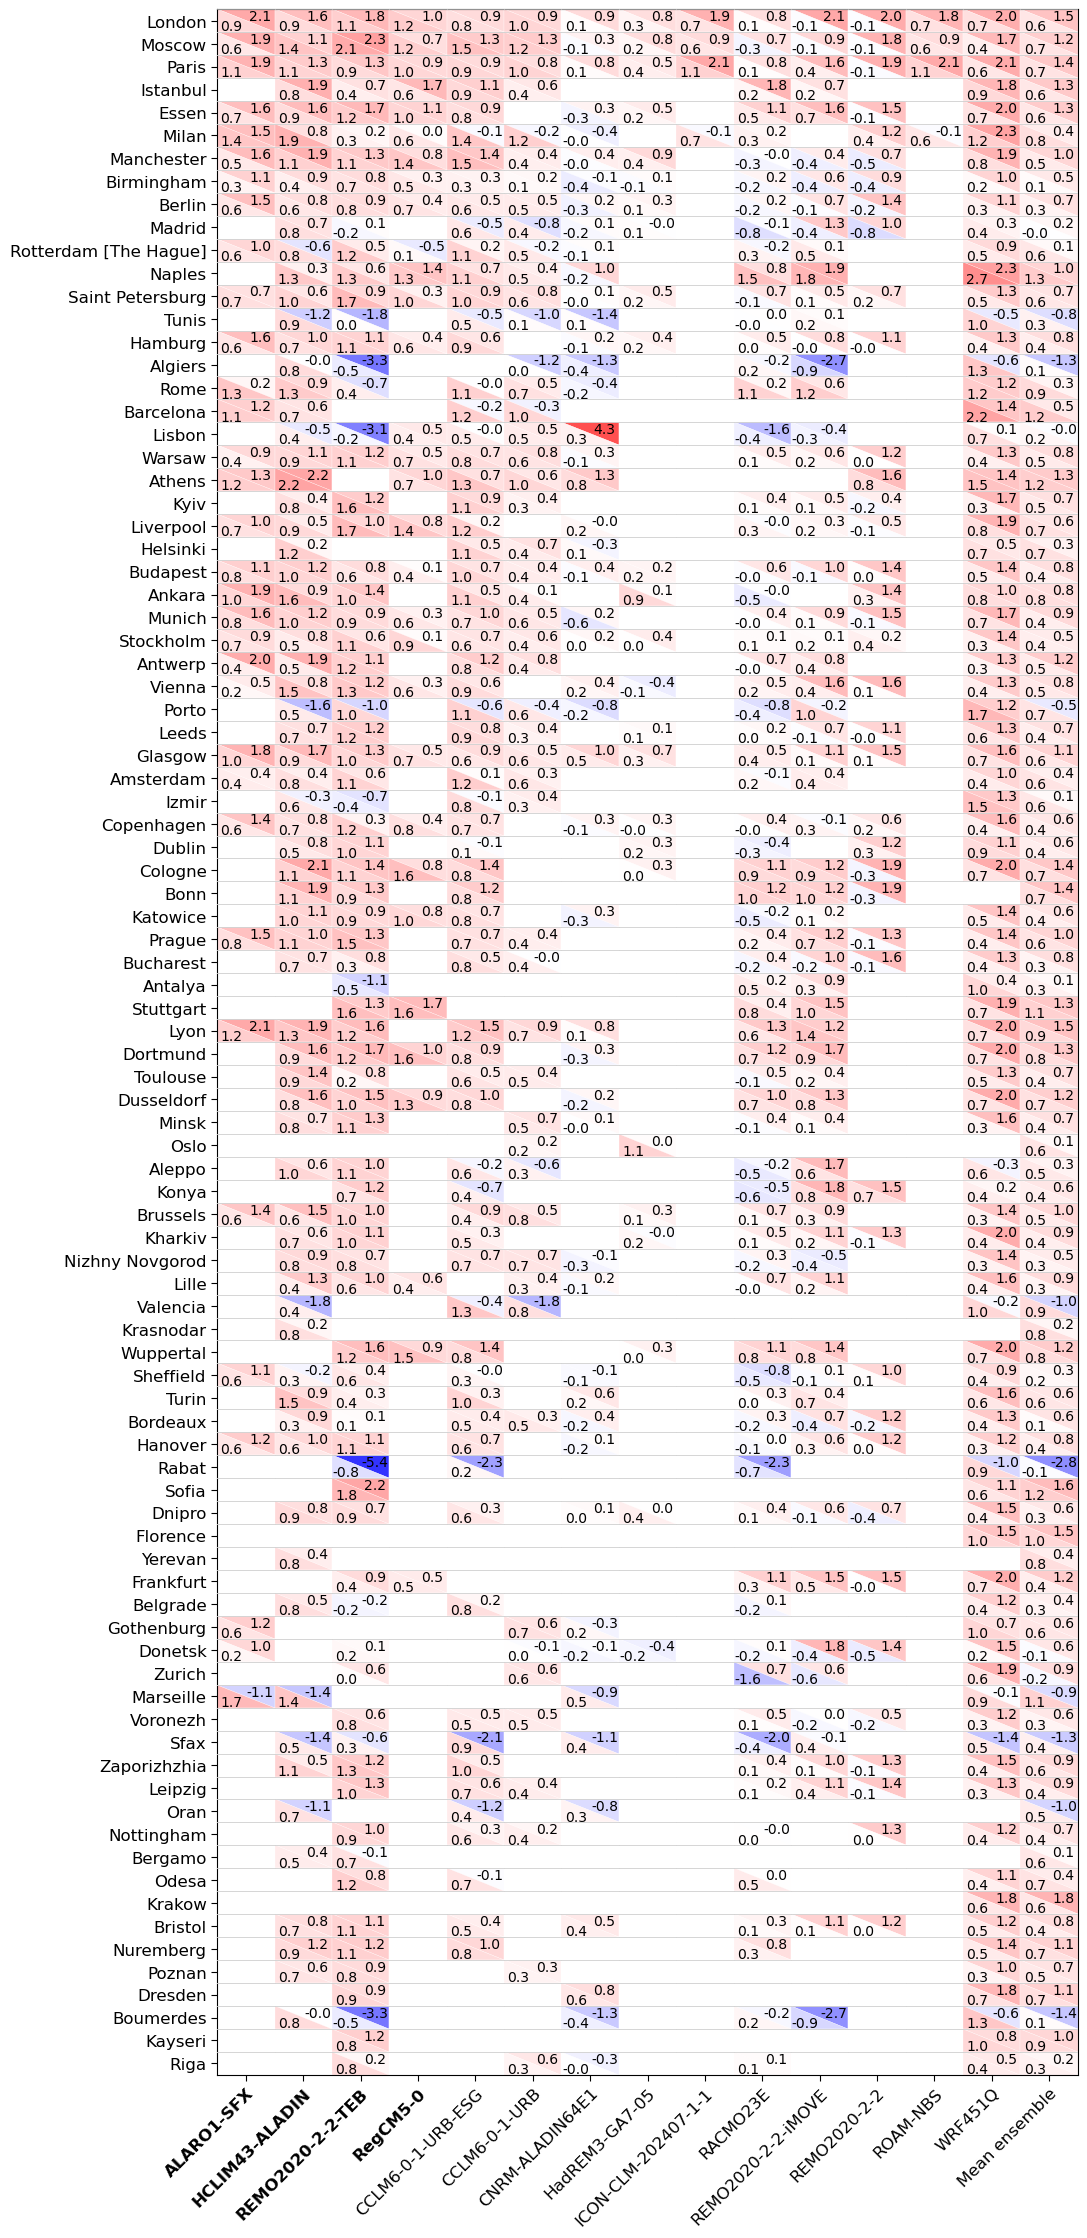

In [17]:
plot_cmip6_seasonal_heatmap(
    cities=cities,
    rcm_names=ordered_rcm_names,
    variable=variable,
    period=period,
    save_figure_dataset=save_figure_dataset,
    save_figure_path=save_figure_path
)

### Maps

In [18]:
def plot_cmip6_ucm_split_map(
    cities,
    gdf_sorted,
    rcm_names,
    variable,
    period,
    save_figure_dataset,
    save_figure_path
):
    """
    Generate seasonal maps showing urban anomaly using split circles.

    Upper half: UCM mean
    Lower half: non-UCM mean
    """
    # =========================================================================
    # 1. Period bounds
    # =========================================================================
    if hasattr(period, "left") and hasattr(period, "right"):
        p_start = int(period.left)
        p_stop = int(period.right)
    else:
        p_start = int(period.start)
        p_stop = int(period.stop)

    # =========================================================================
    # 2. UCM definition
    # =========================================================================
    ucm_models = [
        "ALARO1-SFX_v1-r1",
        "HCLIM43-ALADIN_v1-r1",
        "RegCM5-0_v1-r1",
        "REMO2020-2-2-TEB_v1-r1"
    ]

    ucm_idx = [i for i, name in enumerate(rcm_names) if name in ucm_models]
    non_ucm_idx = [i for i, name in enumerate(rcm_names) if name not in ucm_models]

    # =========================================================================
    # 3. Valid cities
    # =========================================================================
    valid_cities = [c for c in cities if c.lower() != "default"]

    nrows = len(valid_cities)
    ncols = len(rcm_names)

    # =========================================================================
    # 4. Allocate arrays
    # =========================================================================
    summer_means = np.full((nrows, ncols), np.nan)
    winter_means = np.full((nrows, ncols), np.nan)

    # =========================================================================
    # 5. Extract data
    # =========================================================================
    for i, city in enumerate(valid_cities):
        for j, rcm_name in enumerate(rcm_names):

            nc_path = (
                f"{save_figure_dataset}/Annual_cycle/"
                f"CMIP6_{city}_Annual_cycle_{variable}_{rcm_name}_"
                f"{p_start}-{p_stop}.nc"
            )

            mask_path = (
                f"{save_figure_dataset}/urmask/"
                f"CMIP6_{city}_urmask_{rcm_name}.nc"
            )

            if not (os.path.exists(nc_path) and os.path.exists(mask_path)):
                continue

            try:
                with xr.open_dataset(nc_path) as ds, xr.open_dataset(mask_path) as mk:

                    data = ds[variable]

                    data = data.assign_coords({
                        mk.cf["X"].name: mk[mk.cf["X"].name],
                        mk.cf["Y"].name: mk[mk.cf["Y"].name],
                    })

                    urban = data.where(mk["urmask"] == 1)

                    urban_mean = urban.mean(
                        dim=[data.cf["Y"].name, data.cf["X"].name]
                    ).compute()

                    if "time" in urban_mean.dims:
                        months = urban_mean["time.month"].values
                    else:
                        months = np.arange(1, 13)

                    values = urban_mean.values

                    summer_means[i, j] = np.nanmean(
                        values[np.isin(months, [6, 7, 8])]
                    )
                    winter_means[i, j] = np.nanmean(
                        values[np.isin(months, [12, 1, 2])]
                    )

            except Exception as e:
                print(f"Warning: failed processing {city} | {rcm_name} → {e}")

    # =========================================================================
    # 6. Mapping dataframe
    # =========================================================================
    df_map = gdf_sorted[
        gdf_sorted["GC_UCN_MAI_2025"].isin(valid_cities)
    ].copy()

    df_map = df_map.set_index("GC_UCN_MAI_2025").loc[valid_cities].reset_index()

    df_map["lon"] = df_map.geometry_centroid.x
    df_map["lat"] = df_map.geometry_centroid.y

    df_map["winter_ucm"] = (
        np.nanmean(winter_means[:, ucm_idx], axis=1) if ucm_idx else np.nan
    )
    df_map["winter_non_ucm"] = (
        np.nanmean(winter_means[:, non_ucm_idx], axis=1) if non_ucm_idx else np.nan
    )
    df_map["summer_ucm"] = (
        np.nanmean(summer_means[:, ucm_idx], axis=1) if ucm_idx else np.nan
    )
    df_map["summer_non_ucm"] = (
        np.nanmean(summer_means[:, non_ucm_idx], axis=1) if non_ucm_idx else np.nan
    )

    # =========================================================================
    # 7. Colormap
    # ========================================================================    
    if variable in ["tasmin", "tasmax"]:
    
        vmin, vmax, step = -3, 3, 0.5
        levels = np.arange(vmin, vmax + step, step)
        colors = [
            "#000000",
            "#151359",
            "#00438f",
            "#00818f",
            "#00ff00",
            "#ccff33",
            "#ffff00",
            "#ffaa00",
            "#ff7b00",
            "#cc0000", 
            "#8b0000",  
            "#4b0082", 
        ]
    
        cmap = ListedColormap(colors)
    elif variable == "sfcWind":
        cmap = plt.cm.PiYG
        vmin, vmax, step = -1.5, 1.5, 0.25
    else:
        cmap = plt.cm.BrBG
        vmin, vmax, step = -10, 10, 2

    levels = np.arange(vmin, vmax + step, step)
    norm = BoundaryNorm(levels, cmap.N, clip=True)

    # =========================================================================
    # 8. Dynamic legend filtering
    # =========================================================================
    all_vals = np.concatenate([
        df_map["winter_ucm"].values,
        df_map["winter_non_ucm"].values,
        df_map["summer_ucm"].values,
        df_map["summer_non_ucm"].values,
    ])
    all_vals = all_vals[~np.isnan(all_vals)]
    used_bins = set(np.digitize(all_vals, levels, right=False))

    interval_labels = []
    colors = []

    for i in range(len(levels) - 1):
        if (i + 1) not in used_bins:
            continue
        a, b = levels[i], levels[i + 1]
        interval_labels.append(f"{a}–{b}")
        colors.append(cmap(norm((a + b) / 2)))

    handles = [
        Line2D([0], [0],
               marker='o',
               color='none',
               markerfacecolor=c,
               markersize=12,
               label=lab)
        for c, lab in zip(colors, interval_labels)
    ]

    # =========================================================================
    # 9. Figure
    # =========================================================================
    fig, axes = plt.subplots(
        1, 2,
        figsize=(20, 7),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    plt.subplots_adjust(left=0.08, right=0.98, wspace=0.06)

    radius = 0.45
    margin = radius * 4

    # EXTENT WITH SAFE MARGIN
    base_extent = [
        -20 - margin,
        45 + margin,
        35 - margin,
        65 + margin
    ]

    def plot_split_circle(ax, lon, lat, upper, lower):
        if not np.isnan(upper):
            ax.add_patch(Wedge(
                (lon, lat), radius, 0, 180,
                facecolor=cmap(norm(upper)),
                edgecolor="black", linewidth=0.35,
                transform=ccrs.PlateCarree(), zorder=5))

        if not np.isnan(lower):
            ax.add_patch(Wedge(
                (lon, lat), radius, 180, 360,
                facecolor=cmap(norm(lower)),
                edgecolor="black", linewidth=0.35,
                transform=ccrs.PlateCarree(), zorder=5))

    seasons = [
        ("Winter (DJF)", "winter_ucm", "winter_non_ucm"),
        ("Summer (JJA)", "summer_ucm", "summer_non_ucm")
    ]

    for ax, (title, upper_col, lower_col) in zip(axes, seasons):

        ax.set_extent(base_extent, crs=ccrs.PlateCarree())

        ax.add_feature(cfeature.LAND, facecolor="white")
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

        ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.35)

        for _, row in df_map.iterrows():
            plot_split_circle(
                ax,
                row["lon"],
                row["lat"],
                row[upper_col],
                row[lower_col]
            )

        ax.set_title(title, fontsize=14, fontweight="bold")

    # =========================================================================
    # 10. Legend
    # =========================================================================
    axes[0].legend(
        handles=handles,
        title=variable,
        loc="upper left",
        bbox_to_anchor=(0.01, 0.99),
        frameon=True,
        fontsize=12,
        title_fontsize=13
    )

    # =========================================================================
    # 11. Save
    # =========================================================================
    output_dir = os.path.join(save_figure_path, "summaries")
    os.makedirs(output_dir, exist_ok=True)

    filename = f"CMIP6_UCM_split_map_{variable}_{p_start}-{p_stop}"

    png_path = os.path.join(output_dir, filename + ".png")
    pdf_path = os.path.join(output_dir, filename + ".pdf")

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")

    print("Saved:", png_path)
    print("Saved:", pdf_path)

/tmp/ipykernel_4098545/2434454457.py:96: RuntimeWarning: Mean of empty slice
  summer_means[i, j] = np.nanmean(
/tmp/ipykernel_4098545/2434454457.py:99: RuntimeWarning: Mean of empty slice
  winter_means[i, j] = np.nanmean(
/tmp/ipykernel_4098545/2434454457.py:96: RuntimeWarning: Mean of empty slice
  summer_means[i, j] = np.nanmean(
/tmp/ipykernel_4098545/2434454457.py:99: RuntimeWarning: Mean of empty slice
  winter_means[i, j] = np.nanmean(
/tmp/ipykernel_4098545/2434454457.py:96: RuntimeWarning: Mean of empty slice
  summer_means[i, j] = np.nanmean(
/tmp/ipykernel_4098545/2434454457.py:99: RuntimeWarning: Mean of empty slice
  winter_means[i, j] = np.nanmean(
/tmp/ipykernel_4098545/2434454457.py:96: RuntimeWarning: Mean of empty slice
  summer_means[i, j] = np.nanmean(
/tmp/ipykernel_4098545/2434454457.py:99: RuntimeWarning: Mean of empty slice
  winter_means[i, j] = np.nanmean(
/tmp/ipykernel_4098545/2434454457.py:96: RuntimeWarning: Mean of empty slice
  summer_means[i, j] = np.n

Saved: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_UCM_split_map_tasmax_1991-2020.png
Saved: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_UCM_split_map_tasmax_1991-2020.pdf


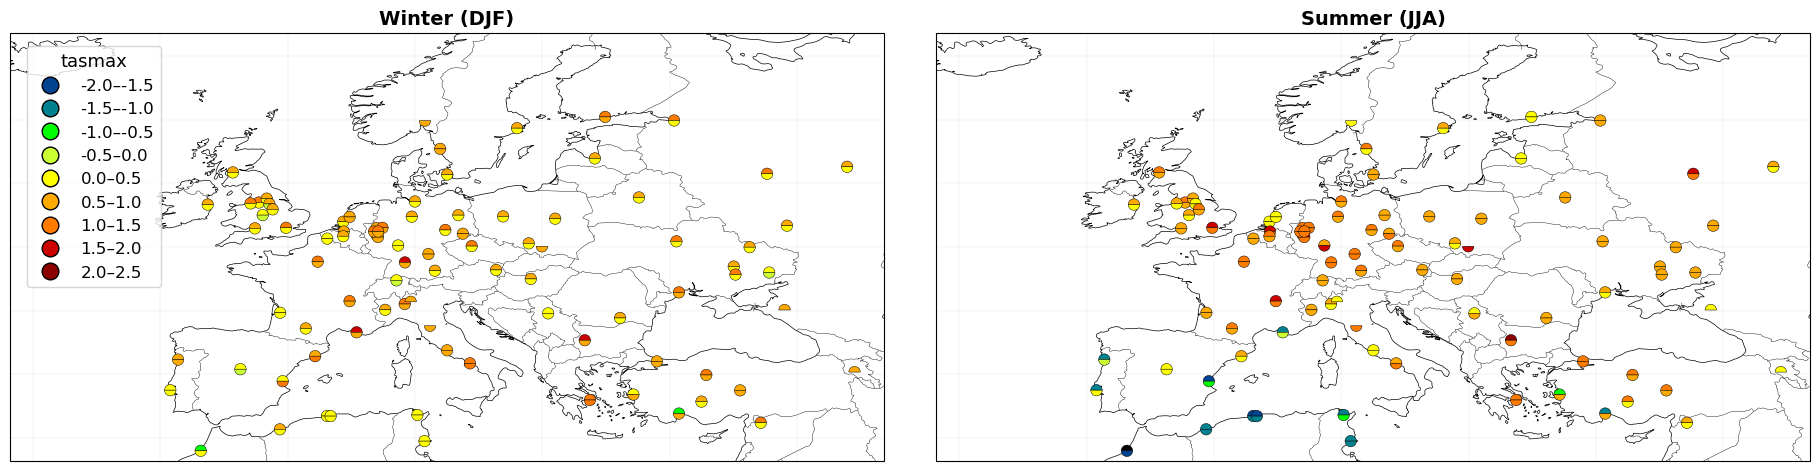

In [19]:
plot_cmip6_ucm_split_map(
    cities=cities,
    gdf_sorted=gdf_sorted,
    rcm_names=ordered_rcm_names,
    variable= variable,
    period=period,
    save_figure_dataset=save_figure_dataset,
    save_figure_path=save_figure_path
)

## Boxplots

In [20]:
root_aux_data = "/mnt/CORDEX_CMIP6_tmp/aux_data/"
ucdb_path = f"{root_aux_data}GHS_FUA_UCD/GHS_UCDB_GLOBE_R2024A.gpkg"

# Load UCDB layers
gdf_centroids = gpd.read_file(ucdb_path, layer="UC_centroids")
gdf_char = gpd.read_file(ucdb_path, layer="GHS_UCDB_THEME_GENERAL_CHARACTERISTICS_GLOBE_R2024A")

# Clean column names
gdf_centroids.columns = gdf_centroids.columns.str.strip().str.replace("﻿", "", regex=True)
gdf_char.columns = gdf_char.columns.str.strip().str.replace("﻿", "", regex=True)

# Reproject to WGS84
gdf_centroids = gdf_centroids.to_crs(epsg=4326)

# Merge centroid geometry with characteristics
gdf_merged = gdf_char.merge(
    gdf_centroids[["ID_UC_G0", "geometry"]],
    on="ID_UC_G0",
    suffixes=("_char", "_centroid")
)

# Set the geometry to the centroid geometry
gdf_merged = gdf_merged.set_geometry("geometry_centroid")

# Extract lon/lat for filtering
lon_tmp = gdf_merged.geometry.x
lat_tmp = gdf_merged.geometry.y


# Filter cities by area and Europe bounding box
gdf_filtered = gdf_merged[gdf_merged["GC_UCA_KM2_2025"] >= 12.5 * 12.5].copy()
gdf_europe = gdf_filtered[
    (lat_tmp >= 34) & (lat_tmp <= 72) &
    (lon_tmp >= -25) & (lon_tmp <= 45)
].copy()


# ----------------------------------------------------------------------
# PREPARE CITY-COUNTRY LIST
# ----------------------------------------------------------------------
gdf_europe["GC_UCN_MAI_2025"] = gdf_europe["GC_UCN_MAI_2025"].apply(clean_string)
gdf_europe["GC_CNT_GAD_2025"] = gdf_europe["GC_CNT_GAD_2025"].apply(clean_string)
city_country_list = list(zip(gdf_europe["GC_UCN_MAI_2025"], gdf_europe["GC_CNT_GAD_2025"]))
print(f"Filtered European cities (≥144 km²): {len(gdf_europe)}")

Filtered European cities (≥144 km²): 95


/home/yquintana/.conda/envs/jsc/lib/python3.10/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


### Classification of Cities: Coastal

In [21]:
def is_coastal_from_sftlf_2D(polygon, ds_sftlf, max_dist_km=11.5):
    """
    Determines if an urban area (defined by a polygon) is coastal based on the 
    presence of both low and high land fraction (sftlf) values within a proximity buffer.
    polygon: Polygon o MultiPolygon (en cualquier CRS)
        ds_sftlf (xarray.Dataset): Dataset containing the 'sftlf' variable and 2D lon/lat coordinates.
        max_dist_km (float): The search radius around the polygon, expressed in kilometers.
    """
    geom_gs = gpd.GeoSeries([polygon], crs="ESRI:54009").to_crs(epsg=4326)
    poly = geom_gs.iloc[0]
    
    # Buffer
    buffer_deg = max_dist_km / 111.0
    
    # Coordenadates of sftlf
    lon = ds_sftlf.lon.values
    lat = ds_sftlf.lat.values
    sftlf = ds_sftlf.sftlf.values
    
    #create mask of point inside the polygon with the buffer
    points_inside = []
    for j in range(lat.shape[0]):
        for i in range(lon.shape[1]):
            # punto lon/lat
            x, y = lon[j,i], lat[j,i]
            # solo puntos dentro del bbox + buffer
            if (poly.bounds[0]-buffer_deg <= x <= poly.bounds[2]+buffer_deg) and \
               (poly.bounds[1]-buffer_deg <= y <= poly.bounds[3]+buffer_deg):
                points_inside.append((x,y,sftlf[j,i]))
    
    if not points_inside:
        return False
    
    sftlf_vals = np.array([p[2] for p in points_inside])
    return (np.nanmax(sftlf_vals) > 70) and (np.nanmin(sftlf_vals) < 70)


In [22]:
ds_sftlf = xr.open_dataset("/mnt/CORDEX_CMIP6_tmp/sim_data/CORDEX-CMIP6/DD/EUR-12/ICTP/MPI-ESM1-2-HR/historical/r1i1p1f1/RegCM5-0/v1-r1/fx/sftlf/v20250415/sftlf_EUR-12_MPI-ESM1-2-HR_historical_r1i1p1f1_ICTP_RegCM5-0_v1-r1_fx.nc") 
gdf_europe["is_coastal"] = gdf_europe["geometry_char"].apply(
    lambda geom: is_coastal_from_sftlf_2D(geom, ds_sftlf)
)

### Classification of Cities: Mountain

In [23]:
def get_elevation_from_orog_2d(point, ds):
    """
    Retrieves elevation from 2D xarray grid based on the nearest grid cell to a given point.
    
    Args:
        point (shapely Point): City centroid geometry.
        ds (xarray.Dataset): Dataset containing orog (elevation), lat, and lon (2D arrays).
    
    Returns:
        float: Elevation value at the nearest grid point.
    """
    # Calculate squared approximate Euclidean distance in degrees to find the nearest grid point
    dist2 = (ds.lat - point.y)**2 + (ds.lon - point.x)**2
    
    # Get the 2D indices (y_idx, x_idx) of the minimum distance
    y_idx, x_idx = np.unravel_index(dist2.argmin().item(), dist2.shape)
    
    # Return the elevation value (orog) at the identified index
    return float(ds.orog[y_idx, x_idx].values)


In [24]:
ds_orog = xr.open_dataset("/mnt/CORDEX_CMIP6_tmp/sim_data/CORDEX-CMIP6/DD/EUR-12/ICTP/MPI-ESM1-2-HR/historical/r1i1p1f1/RegCM5-0/v1-r1/fx/orog/v20250415/orog_EUR-12_MPI-ESM1-2-HR_historical_r1i1p1f1_ICTP_RegCM5-0_v1-r1_fx.nc") 
# Apply the function to the city centroids to calculate the nearest elevation and store it
gdf_europe["elevation"] = gdf_europe.geometry_centroid.apply(
    lambda p: get_elevation_from_orog_2d(p, ds_orog)
)
# Classify cities as 'is_mountain' if their elevation is 500 meters or higher
gdf_europe["is_mountain"] = gdf_europe["elevation"] >= 500

We have successfully completed the initial geographical classification of all analyzed European cities. This process involved the creation of two distinct binary classification variables:

    Coastal: Cities located on or near a major coastline (is_coastal = True).

    Mountainous: Cities whose elevation meets or exceeds the defined threshold (e.g., ≥500 m) (is_mountain = True).

    Inland: The remaining cities, which are neither classified as Coastal nor as Mountainous, fall into the Inland category. These cities represent the purely continental environment within the dataset.

In [25]:
gdf_europe["is_inland"] = (~gdf_europe["is_coastal"]) & (~gdf_europe["is_mountain"])

In [26]:
def get_city_type(row):
    if row["is_mountain"]:
        return "Mountain"
    elif row["is_coastal"]:
        return "Coastal"
    elif row["is_inland"]:
        return "Inland"

gdf_europe["city_type"] = gdf_europe.apply(get_city_type, axis=1)

In [27]:
period = pd.Interval(left=1991, right=2020, closed='both')

### Model Configuration

In [28]:
csv_path = "eurocordex_models_urban.csv"

# Read CSV without comment="#" so color fields starting with '#' are kept
models_df = pd.read_csv(csv_path, sep=",", engine="python", dtype=str)

# Strip whitespace from column names (defensive)
models_df.columns = [c.strip() for c in models_df.columns]

# --- Check that all required columns exist (now includes 'urban') ---
required_cols = {"model", "mip_era", "color", "urban"}
if not required_cols.issubset(set(models_df.columns)):
    raise RuntimeError(
        f"Missing columns in {csv_path}. Required: {required_cols}. "
        f"Found: {models_df.columns.tolist()}"
    )

# --- Filter only CMIP6 models ---
models_cmip6 = models_df[models_df["mip_era"].str.strip() == "CMIP6"].copy()


models_cmip6["color"] = models_cmip6["color"].apply(clean_color)

# --- Match models to your RCM names (base name before version) ---
rcm_base_names = [name.split("_v")[0] for name in rcm_names]
models_plot = models_cmip6[models_cmip6["model"].isin(rcm_base_names)].copy()

# --- Create color and style mapping dicts ---
model_colors = {}
model_styles = {}  # new: line/marker styles

for rcm_name in rcm_names:
    base = rcm_name.split("_v")[0]
    row = models_plot.loc[models_plot["model"] == base]
    
    if not row.empty:
        color = row["color"].values[0]
        urban = row["urban"].values[0].strip() if "urban" in row.columns else ""
        
        # assign color
        model_colors[rcm_name] = color if pd.notna(color) else "#999999"
        

## Plot a boxplot for each variable

### Load the data

In [29]:
vmin, vmax = -3, 3
variables = ["tasmin", "tasmax",  'sfcWind', 'hurs']  

In [30]:
def extract_cmip6_seasonal_records(
    variables,
    gdf_europe,
    rcm_names,
    period,
    save_figure_dataset
):
    """
    Extract seasonal (JJA / DJF) mean urban anomalies for multiple variables,
    cities and RCMs.

    Returns
    -------
    records : list of dict
        Each entry contains City, City_Type, Model, Variable, Season and Value.
    """

    records = []

    for variable in variables:
        for city, city_type in zip(
            gdf_europe["GC_UCN_MAI_2025"],
            gdf_europe["city_type"]
        ):

            city_file = city  # already sanitized upstream

            for rcm_name in rcm_names:

                nc_path = (
                    f"{save_figure_dataset}/Annual_cycle/"
                    f"CMIP6_{city_file}_Annual_cycle_{variable}_{rcm_name}_"
                    f"{period.left}-{period.right}.nc"
                )
                urmask_path = (
                    f"{save_figure_dataset}/urmask/"
                    f"CMIP6_{city_file}_urmask_{rcm_name}.nc"
                )

                if not (os.path.exists(nc_path) and os.path.exists(urmask_path)):
                    continue

                try:
                    # ---------------------------------------------------------
                    # Load data
                    # ---------------------------------------------------------
                    ds_anomaly = xr.open_dataset(nc_path)[variable]
                    urmask = xr.open_dataset(urmask_path)

                    # Align coordinates
                    ds_anomaly = ds_anomaly.assign_coords({
                        urmask.cf["X"].name: urmask[urmask.cf["X"].name],
                        urmask.cf["Y"].name: urmask[urmask.cf["Y"].name],
                    })

                    # Apply urban mask
                    is_urban = urmask["urmask"] == 1
                    if is_urban.sum() == 0:
                        continue

                    urban_anomaly = ds_anomaly.where(is_urban)

                    # Spatial mean
                    urban_mean = urban_anomaly.mean(
                        dim=[ds_anomaly.cf["Y"].name, ds_anomaly.cf["X"].name]
                    ).compute()

                    # ---------------------------------------------------------
                    # Temporal handling
                    # ---------------------------------------------------------
                    if "time" in urban_mean.dims:
                        months = urban_mean["time.month"].values
                        values = urban_mean.values
                    else:
                        months = np.arange(1, 13)
                        values = urban_mean.values
                        if values.ndim == 0:
                            values = np.array([values])

                    jja_mask = np.isin(months, [6, 7, 8])
                    djf_mask = np.isin(months, [12, 1, 2])

                    summer_mean = (
                        np.nan if values[jja_mask].size == 0
                        else np.nanmean(values[jja_mask])
                    )
                    winter_mean = (
                        np.nan if values[djf_mask].size == 0
                        else np.nanmean(values[djf_mask])
                    )

                    # ---------------------------------------------------------
                    # Store records
                    # ---------------------------------------------------------
                    records.append({
                        "City": city,
                        "City_Type": city_type,
                        "Model": rcm_name,
                        "Variable": variable,
                        "Season": "Summer (JJA)",
                        "Value": summer_mean,
                    })
                    records.append({
                        "City": city,
                        "City_Type": city_type,
                        "Model": rcm_name,
                        "Variable": variable,
                        "Season": "Winter (DJF)",
                        "Value": winter_mean,
                    })

                except Exception as e:
                    print(f"Error in {city} - {rcm_name} - {variable}: {e}")
                    continue

    return records

In [31]:
records = extract_cmip6_seasonal_records(
    variables=variables,
    gdf_europe=gdf_europe,
    rcm_names=rcm_names,
    period=period,
    save_figure_dataset=save_figure_dataset
)

/tmp/ipykernel_4098545/3957945991.py:85: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/3957945991.py:89: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/3957945991.py:85: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/3957945991.py:89: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/3957945991.py:85: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/3957945991.py:89: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/3957945991.py:85: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/3957945991.py:89: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/3957945991.py:85: RuntimeWarning: Mean of empty slice
  else np.nanmean(v

Error in Leeds - CCLM6-0-1-URB_v1-r1 - hurs: "No variable named 'hurs'. Variables on the dataset include []"


/tmp/ipykernel_4098545/3957945991.py:85: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/3957945991.py:89: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/3957945991.py:85: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/3957945991.py:89: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/3957945991.py:85: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/3957945991.py:89: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/3957945991.py:85: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/3957945991.py:89: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/3957945991.py:85: RuntimeWarning: Mean of empty slice
  else np.nanmean(v

### Plot the data

In [32]:
model_color_map = dict(zip(models_plot["model"], models_plot["color"]))

In [33]:
def plot_boxplots_all_variables(
    records,
    model_color_map,
    period,
    save_summary_path
):
    """
    Generate faceted boxplots for multiple climate variables across city types
    and seasons. The plot shows the distribution of model values, including
    individual model ranges and values.

    Parameters
    ----------
    records : list of dict
        List containing model output data. Each record must contain:
        ['Model', 'Variable', 'Season', 'City_Type', 'Value'].

    model_color_map : dict
        Mapping between model base names and plotting colors.

    period : pandas.Interval or object
        Time period used to label the output figures.

    save_summary_path : str
        Directory where the figures will be saved.

    Returns
    -------
    None
        Saves PNG and PDF figures to disk.
    """
    # --------------------------------------------------
    # DataFrame construction
    # --------------------------------------------------
    df_box = pd.DataFrame(records)

    if df_box.empty:
        print("df_box is empty; no data available for plotting.")
        return

    # --------------------------------------------------
    # Combine season and city type
    # --------------------------------------------------
    df_box["Type_Season"] = (
        df_box["Season"].str.replace(r"\s\(.+\)", "", regex=True)
        + " "
        + df_box["City_Type"]
    )

    # --------------------------------------------------
    # Plot style
    # --------------------------------------------------
    sns.set(style="whitegrid", font_scale=1.8)

    city_types = ["Coastal", "Inland", "Mountain"]
    seasons = ["Summer", "Winter"]

    type_season_order = [f"{s} {t}" for s in seasons for t in city_types]

    n_per_season = len(city_types)

    variables = df_box["Variable"].unique()
    n_vars = len(variables)

    fig_width = 3 * n_per_season
    fig_height = 4.2 * n_vars

    fig, axes = plt.subplots(
        n_vars,
        1,
        figsize=(fig_width, fig_height),
        sharex=True
    )

    if n_vars == 1:
        axes = [axes]

    # --------------------------------------------------
    # Plotting loop
    # --------------------------------------------------
    for ax, variable in zip(axes, variables):

        data_plot = df_box[df_box["Variable"] == variable]

        if data_plot.empty:
            continue

        # --------------------------------------------------
        # Model min–max lines
        # --------------------------------------------------
        grouped = (
            data_plot
            .groupby(["Type_Season", "Model"])["Value"]
            .agg(["min", "max"])
            .reset_index()
        )

        model_xpos = {}

        for i, ts in enumerate(type_season_order):

            ts_group = grouped[grouped["Type_Season"] == ts]
            n_models_ts = len(ts_group)

            if n_models_ts == 0:
                continue

            offsets = np.linspace(-0.3, 0.3, n_models_ts)

            for offset, (_, row) in zip(offsets, ts_group.iterrows()):

                model = row["Model"]

                color = model_color_map.get(
                    model.split("_v")[0],
                    "#999999"
                )

                x_pos = i + offset
                model_xpos[(ts, model)] = x_pos

                ax.vlines(
                    x=x_pos,
                    ymin=row["min"],
                    ymax=row["max"],
                    color=color,
                    linewidth=1,
                    alpha=0.9,
                    zorder=1
                )

        # --------------------------------------------------
        # Boxplot
        # --------------------------------------------------
        sns.boxplot(
            data=data_plot,
            x="Type_Season",
            y="Value",
            order=type_season_order,
            ax=ax,
            width=0.75,
            showfliers=False,
            showmeans=True,
            meanprops={
                "marker": "o",
                "markerfacecolor": "black",
                "markeredgecolor": "black",
                "markersize": 7
            },
            palette=["none"] * len(type_season_order),
            linewidth=1.6,
            zorder=20
        )

        # Style box elements
        for patch in ax.patches:
            patch.set_facecolor("none")
            patch.set_edgecolor("black")
            patch.set_linewidth(2.0)
            patch.set_zorder(20)

        for line in ax.lines:
            line.set_color("black")
            line.set_linewidth(1.6)
            line.set_zorder(21)

        # --------------------------------------------------
        # Model points
        # --------------------------------------------------
        jitter_amplitude = 0.035

        for _, row in data_plot.iterrows():

            ts = row["Type_Season"]
            model = row["Model"]

            base_x = model_xpos.get((ts, model))

            if base_x is None:
                continue

            jitter = (np.random.rand() - 0.5) * 2 * jitter_amplitude
            x_pos = base_x + jitter

            color = model_color_map.get(
                model.split("_v")[0],
                "#999999"
            )

            ax.plot(
                x_pos,
                row["Value"],
                "o",
                color=color,
                alpha=0.25,
                markersize=4,
                zorder=10
            )

        # --------------------------------------------------
        # Season separator
        # --------------------------------------------------
        ax.axvline(
            n_per_season - 0.5,
            color="black",
            linestyle="--",
            lw=1.2
        )

        # --------------------------------------------------
        # Axis formatting
        # --------------------------------------------------
        ax.set_xticks(range(len(type_season_order)))

        ax.set_xticklabels(
            [ts.split()[1] for ts in type_season_order],
            fontsize=18,
            rotation=30
        )

        ax.set_xlabel("")

        units = {
            "tasmin": "K",
            "tasmax": "K",
            "pr": "% (mm/day)",
            "sfcWind": "m/s",
            "hurs": "%",
        }.get(variable, "")

        ax.set_ylabel(f"{variable} ({units})", fontsize=20)

        ax.grid(True, axis="y", linestyle="--", alpha=0.6)

    # --------------------------------------------------
    # Season labels
    # --------------------------------------------------
    top_ax = axes[0]
    ylim = top_ax.get_ylim()

    summer_center = (0 + (n_per_season - 1)) / 2
    winter_center = summer_center + n_per_season

    top_ax.text(
        summer_center,
        ylim[1] * 1.05,
        "Summer",
        ha="center",
        va="bottom",
        fontsize=22,
        fontweight="bold"
    )

    top_ax.text(
        winter_center,
        ylim[1] * 1.05,
        "Winter",
        ha="center",
        va="bottom",
        fontsize=22,
        fontweight="bold"
    )

    # --------------------------------------------------
    # Layout
    # --------------------------------------------------
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # --------------------------------------------------
    # Save figure
    # --------------------------------------------------
    filename_base = f"CMIP6_Boxplot_AllCities_AllVariables_{period.left}-{period.right}"

    png_path = os.path.join(save_summary_path, f"{filename_base}.png")
    pdf_path = os.path.join(save_summary_path, f"{filename_base}.pdf")

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

    print(f"Figure saved to: {png_path}")
    print(f"Figure saved to: {pdf_path}")

/tmp/ipykernel_4098545/549658901.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4098545/549658901.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4098545/549658901.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4098545/549658901.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Figure saved to: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Boxplot_AllCities_AllVariables_1991-2020.png
Figure saved to: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Boxplot_AllCities_AllVariables_1991-2020.pdf


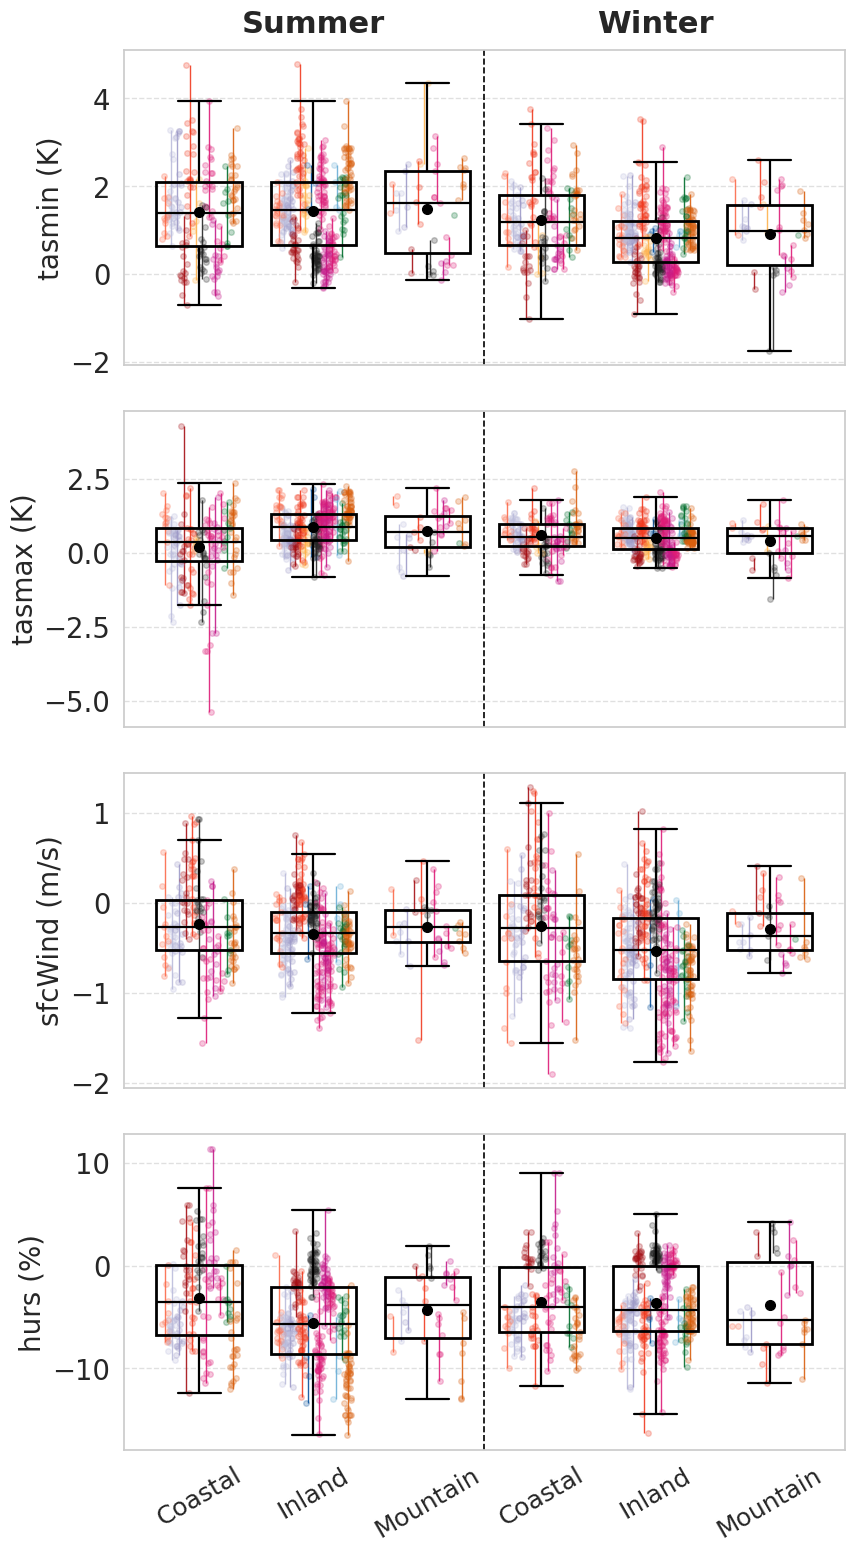

In [34]:
plot_boxplots_all_variables(
    records=records,
    model_color_map=model_color_map,
    period=period,
    save_summary_path=save_summary_path
)

## Analysis and Plots by Urban Area

This section shifts the focus from categorical geographical classification to a quantitative analysis based on the urban area of the cities. The urban area size, measured by the number of grid cells covered, acts as a primary metric for studying scale-dependent effects.

### Load the data

In [35]:
def extract_seasonal_urban_records(
    variables,
    gdf_europe,
    rcm_names,
    save_figure_dataset,
    save_figure_path,
    period
):
    """
    Extract seasonal (JJA and DJF) urban anomaly statistics for all cities,
    models, and variables from stored NetCDF datasets.

    The function loads the anomaly fields, applies the urban mask, computes
    the spatial mean over urban grid cells, and aggregates values for summer
    (JJA) and winter (DJF).

    Parameters
    ----------
    variables : list
        Climate variables to process (e.g., ["tasmin", "tasmax", "pr"]).

    gdf_europe : GeoDataFrame
        GeoDataFrame containing city metadata. Must include columns:
        'GC_UCN_MAI_2025' (city name) and 'city_type'.

    rcm_names : list
        List of regional climate model identifiers.

    save_figure_dataset : str
        Path where the processed NetCDF datasets are stored.

    save_figure_path : str
        Base directory where summary outputs will be saved.

    period : pandas.Interval or similar
        Time period used in dataset filenames.

    Returns
    -------
    records : list of dict
        Extracted seasonal statistics for each city, model, and variable.

    save_summary_path : str
        Directory where summary figures should be stored.
    """
    # --------------------------------------------------
    # Settings
    # --------------------------------------------------
    vmin, vmax = -3, 3

    save_summary_path = os.path.join(save_figure_path, "summaries")
    os.makedirs(save_summary_path, exist_ok=True)

    records = []

    # --------------------------------------------------
    # Data extraction loop
    # --------------------------------------------------
    for variable in variables:

        for city, city_type in zip(
            gdf_europe["GC_UCN_MAI_2025"],
            gdf_europe["city_type"]
        ):

            city_file = city

            for rcm_name in rcm_names:

                nc_path = (
                    f"{save_figure_dataset}/Annual_cycle/"
                    f"CMIP6_{city_file}_Annual_cycle_{variable}_{rcm_name}_{period.left}-{period.right}.nc"
                )

                urmask_path = (
                    f"{save_figure_dataset}/urmask/"
                    f"CMIP6_{city_file}_urmask_{rcm_name}.nc"
                )

                if not (os.path.exists(nc_path) and os.path.exists(urmask_path)):
                    continue

                try:

                    # --------------------------------------------------
                    # Load datasets
                    # --------------------------------------------------
                    ds_anomaly = xr.open_dataset(nc_path)[variable]
                    urmask = xr.open_dataset(urmask_path)

                    # --------------------------------------------------
                    # Align coordinates
                    # --------------------------------------------------
                    ds_anomaly = ds_anomaly.assign_coords({
                        urmask.cf['X'].name: urmask[urmask.cf['X'].name],
                        urmask.cf['Y'].name: urmask[urmask.cf['Y'].name]
                    })

                    # --------------------------------------------------
                    # Apply urban mask
                    # --------------------------------------------------
                    is_urban = urmask["urmask"] == 1
                    urban_cells = int(is_urban.sum().values)

                    if urban_cells == 0:
                        continue

                    urban_anomaly = ds_anomaly.where(is_urban)

                    # --------------------------------------------------
                    # Spatial mean
                    # --------------------------------------------------
                    urban_mean = urban_anomaly.mean(
                        dim=[ds_anomaly.cf["Y"].name, ds_anomaly.cf["X"].name]
                    ).compute()

                    # --------------------------------------------------
                    # Extract monthly values
                    # --------------------------------------------------
                    if "time" in urban_mean.dims:
                        months = urban_mean["time.month"].values
                        values = urban_mean.values
                    else:
                        months = np.arange(1, 13)
                        values = urban_mean.values

                        if values.ndim == 0:
                            values = np.array([values])

                    # --------------------------------------------------
                    # Seasonal means
                    # --------------------------------------------------
                    jja_mask = np.isin(months, [6, 7, 8])
                    djf_mask = np.isin(months, [12, 1, 2])

                    summer_mean = (
                        np.nan if values[jja_mask].size == 0
                        else np.nanmean(values[jja_mask])
                    )

                    winter_mean = (
                        np.nan if values[djf_mask].size == 0
                        else np.nanmean(values[djf_mask])
                    )

                    # --------------------------------------------------
                    # Store results
                    # --------------------------------------------------
                    records.append({
                        "City": city,
                        "City_Type": city_type,
                        "Model": rcm_name,
                        "Variable": variable,
                        "Season": "Summer (JJA)",
                        "Value": summer_mean,
                        "urban_cells": urban_cells
                    })

                    records.append({
                        "City": city,
                        "City_Type": city_type,
                        "Model": rcm_name,
                        "Variable": variable,
                        "Season": "Winter (DJF)",
                        "Value": winter_mean,
                        "urban_cells": urban_cells
                    })

                except Exception as e:
                    print(f"Error in {city} - {rcm_name} - {variable}: {e}")
                    continue

    return records, save_summary_path

In [36]:
records, save_summary_path = extract_seasonal_urban_records(
    variables=variables,
    gdf_europe=gdf_europe,
    rcm_names=rcm_names,
    save_figure_dataset=save_figure_dataset,
    save_figure_path=save_figure_path,
    period=period
)

/tmp/ipykernel_4098545/388995072.py:138: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/388995072.py:143: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/388995072.py:138: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/388995072.py:143: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/388995072.py:138: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/388995072.py:143: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/388995072.py:138: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/388995072.py:143: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/388995072.py:138: RuntimeWarning: Mean of empty slice
  else np.nanmean(v

Error in Leeds - CCLM6-0-1-URB_v1-r1 - hurs: "No variable named 'hurs'. Variables on the dataset include []"


/tmp/ipykernel_4098545/388995072.py:138: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/388995072.py:143: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/388995072.py:138: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/388995072.py:143: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/388995072.py:138: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/388995072.py:143: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/388995072.py:138: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[jja_mask])
/tmp/ipykernel_4098545/388995072.py:143: RuntimeWarning: Mean of empty slice
  else np.nanmean(values[djf_mask])
/tmp/ipykernel_4098545/388995072.py:138: RuntimeWarning: Mean of empty slice
  else np.nanmean(v

### Scatter plot for each variable

### Final plot with all variables

In [37]:
def plot_urban_area_scatter(
    records,
    model_color_map,
    rcm_names,
    period,
    save_summary_path
):
    """
    Clean extracted records and generate combined scatter plots showing
    the relationship between urban area size (number of urban grid cells)
    and climate variable anomalies.

    Each subplot represents a specific variable and season combination.

    Parameters
    ----------
    records : list of dict
        Extracted statistics for each city, model, and variable.

    model_color_map : dict
        Mapping between model base names and plotting colors.

    rcm_names : list
        List of regional climate model identifiers.

    period : pandas.Interval or similar
        Time period used for labeling the output figure.

    save_summary_path : str
        Directory where the figure will be saved.

    Returns
    -------
    None
        Saves the generated figure to disk.
    """
    # --------------------------------------------------
    # DATA CLEANING
    # --------------------------------------------------
    df_box = pd.DataFrame(records).copy()

    # Replace masked values with NaN
    df_box["Value"] = df_box["Value"].apply(
        lambda x: np.nan if (isinstance(x, np.ma.MaskedArray) or np.ma.is_masked(x)) else x
    )

    # Remove rows with missing values
    df_box = df_box.dropna(subset=["Value"])

    # Ensure City_Type is valid
    df_box["City_Type"] = df_box["City_Type"].astype(str).replace("nan", "Unknown")

    if df_box.empty:
        print("No valid data available after cleaning.")
        return

    # --------------------------------------------------
    # PLOT SETTINGS
    # --------------------------------------------------
    sns.set(style="whitegrid", font_scale=1.2)

    seasons_to_plot = ["Summer (JJA)", "Winter (DJF)"]
    variables = df_box["Variable"].unique()

    n_rows = len(seasons_to_plot)
    n_cols = len(variables)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 5 * n_rows),
        sharex=True
    )

    if n_rows == 1:
        axes = [axes]

    # --------------------------------------------------
    # SCATTER PLOT LOOP
    # --------------------------------------------------
    for r, season in enumerate(seasons_to_plot):
        for c, variable in enumerate(variables):

            ax = axes[r][c] if n_rows > 1 else axes[c]

            data_plot = df_box[
                (df_box["Season"] == season) &
                (df_box["Variable"] == variable)
            ].copy()

            if data_plot.empty:
                ax.set_visible(False)
                continue

            # Plot individual model points
            for _, row in data_plot.iterrows():

                model_base = row["Model"].split("_v")[0] if "Model" in row else None

                color = model_color_map.get(model_base, "#999999")

                ax.scatter(
                    row["urban_cells"],
                    row["Value"],
                    s=70,
                    color=color,
                    edgecolor="k",
                    alpha=0.8,
                    zorder=3
                )

            # Mean reference line
            mean_val = data_plot["Value"].mean()

            ax.axhline(
                mean_val,
                color="black",
                linestyle="--",
                lw=1.5,
                label="Mean"
            )

            # --------------------------------------------------
            # Axis labels
            # --------------------------------------------------
            units = {
                "tasmin": "K",
                "tasmax": "K",
                "pr": "% (mm/day)",
                "sfcWind": "m/s",
                "hurs": "%",
            }.get(variable, "")

            ax.set_title(f"{variable} ({season})", fontsize=14)

            ax.set_ylabel(f"{variable} ({units})", fontsize=12)

            if r == n_rows - 1:
                ax.set_xlabel("Number of urban cells", fontsize=12)
            else:
                ax.set_xlabel("")

            ax.grid(True, linestyle="--", alpha=0.6)

    # --------------------------------------------------
    # LEGEND
    # --------------------------------------------------
    legend_elements = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=m.split("_v")[0],
            markerfacecolor=model_color_map.get(m.split("_v")[0], "#999999"),
            markeredgecolor="k",
            markersize=8
        )
        for m in rcm_names
    ]

    fig.legend(
        handles=legend_elements,
        loc="upper right",
        title="Models",
        fontsize=16
    )

    # --------------------------------------------------
    # LAYOUT
    # --------------------------------------------------
    plt.tight_layout(rect=[0, 0, 0.88, 1])

    # --------------------------------------------------
    # SAVE FIGURE
    # --------------------------------------------------
    output_png_path = os.path.join(
        save_summary_path,
        f"CMIP6_Scatter_UrbanArea_AllVars_AllSeasons_{period.left}-{period.right}.png"
    )

    fig.savefig(
        output_png_path,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Combined scatter plot saved to: {output_png_path}")

Combined scatter plot saved to: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Scatter_UrbanArea_AllVars_AllSeasons_1991-2020.png


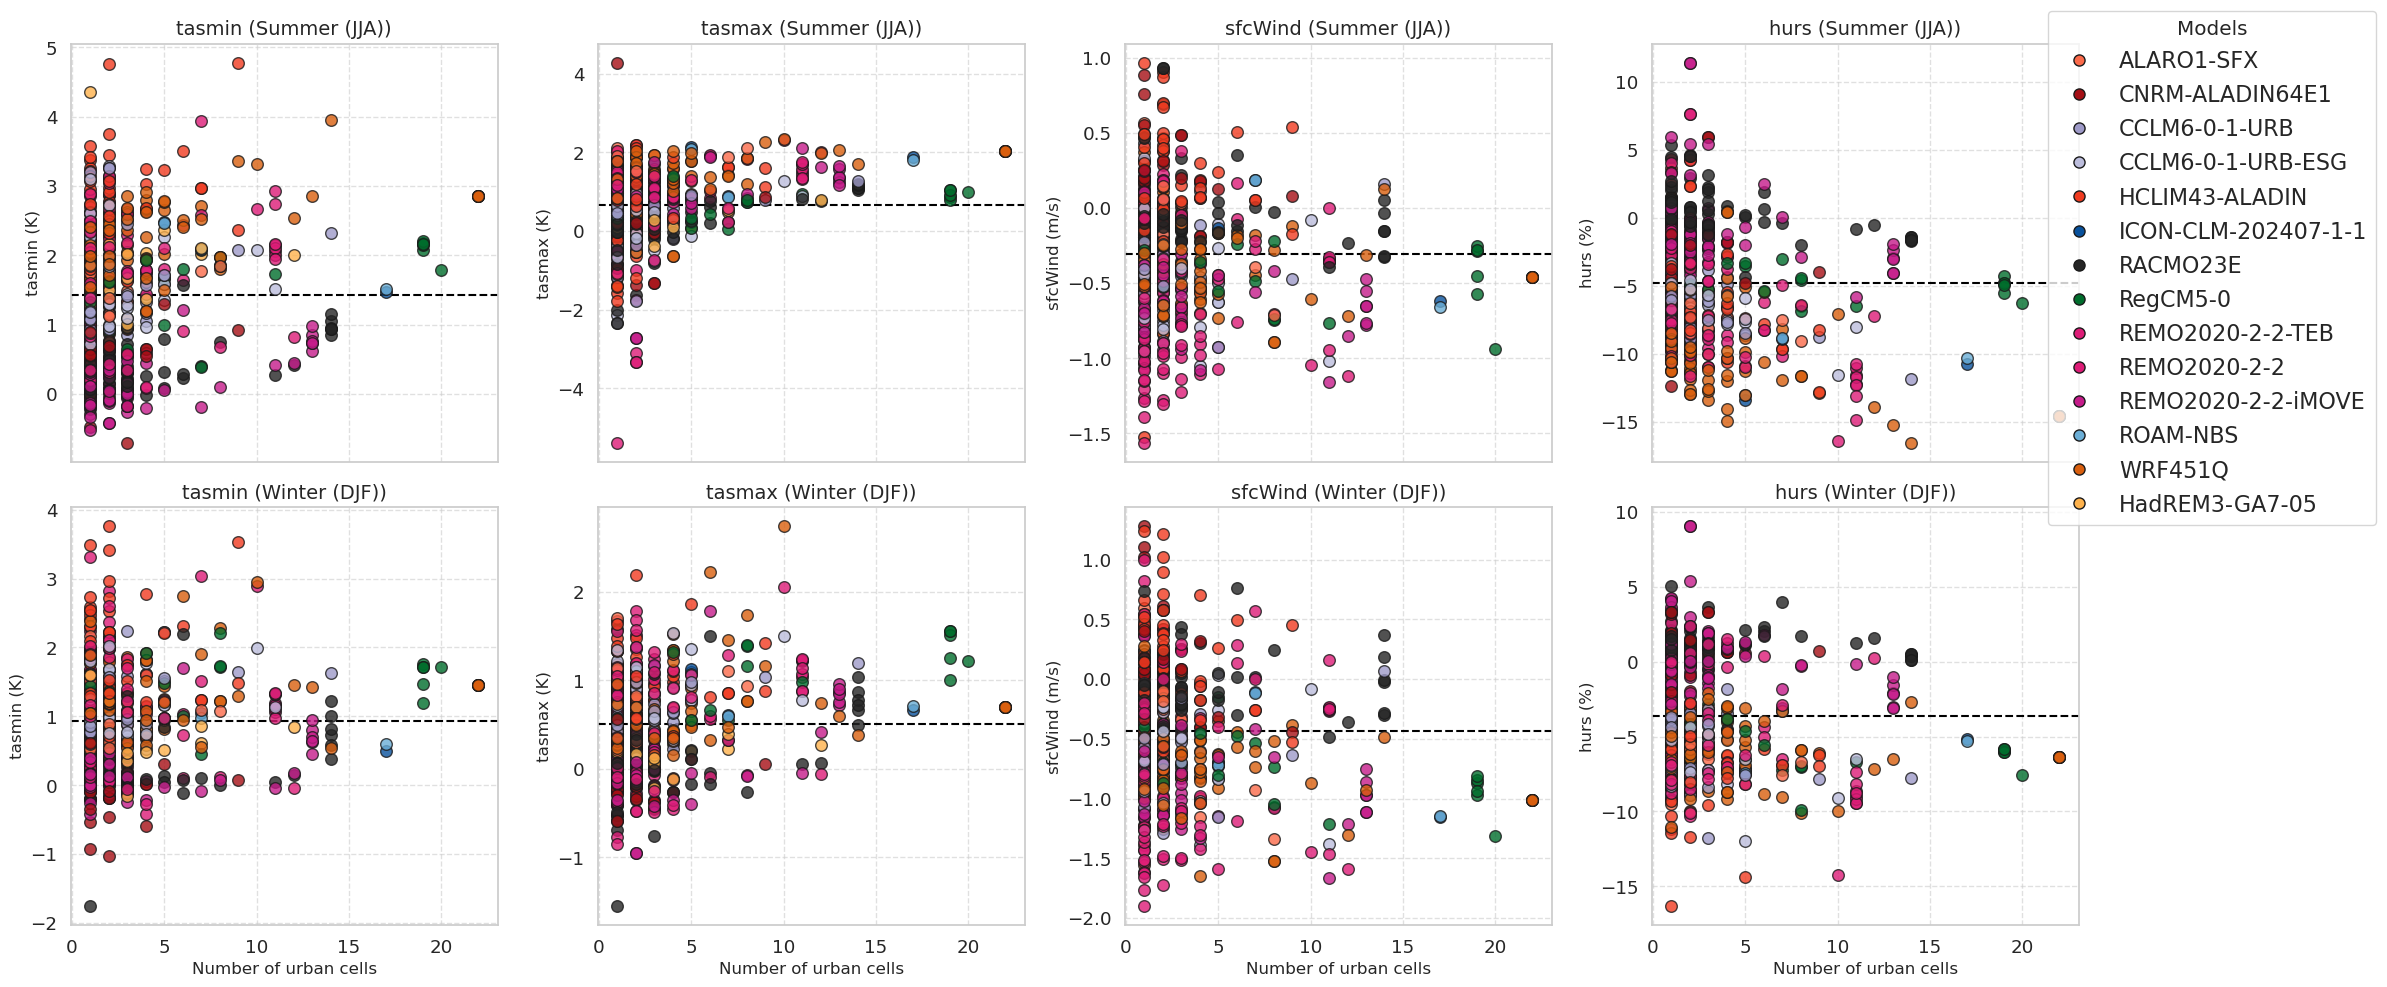

In [38]:
plot_urban_area_scatter(
    records=records,
    model_color_map=model_color_map,
    rcm_names=rcm_names,
    period=period,
    save_summary_path=save_summary_path
)

### Boxplot with number of cells

In [39]:
models_plot = models_cmip6[models_cmip6["model"].isin(rcm_base_names)].copy()

## Analysis and Plots by Urban Scheme (Slab vs. UCM)

This section focuses on comparing the simulation results based on the type of Urban Scheme implemented in the Regional Climate Models (RCMs). The primary objective is to highlight differences and similarities between two key simplified urban representations: the BULK model and the Urban Canopy Model (UCM).

### Boxplot for each variable

### Final plot with all variables

In [40]:
def plot_boxplots_by_urban_scheme(
    records,
    models_plot,
    model_color_map,
    period,
    save_summary_path
):
    """
    Generate faceted boxplots comparing climate variable anomalies by
    urban scheme (UCM vs BULK) and season.

    The plot includes:
    - Model min–max ranges (vertical lines)
    - Distribution boxplots across all cities
    - Individual model values
    - Seasonal grouping

    Parameters
    ----------
    records : list of dict
        Extracted seasonal statistics for all cities, models, and variables.

    models_plot : pandas.DataFrame
        DataFrame containing model metadata. Must include columns:
        ['model', 'urban'] describing the urban scheme.

    model_color_map : dict
        Mapping between model base names and plotting colors.

    period : pandas.Interval or similar
        Time period used in output filenames.

    save_summary_path : str
        Directory where figures will be saved.

    Returns
    -------
    None
        Saves PNG and PDF figures.
    """
    # --------------------------------------------------
    # DATA PREPARATION
    # --------------------------------------------------
    df_box = pd.DataFrame(records).copy()

    if df_box.empty:
        print("df_box is empty; no data available for plotting.")
        return

    # Extract base model name
    df_box["Model_Base"] = df_box["Model"].str.split("_v").str[0]

    # Merge urban scheme metadata
    df_box = df_box.merge(
        models_plot[["model", "urban"]],
        left_on="Model_Base",
        right_on="model",
        how="left"
    ).drop(columns=["model"])

    # Assign model colors
    df_box["color"] = df_box["Model_Base"].map(model_color_map)

    # --------------------------------------------------
    # Normalize urban scheme labels
    # --------------------------------------------------
    def normalize_urban(u):

        if isinstance(u, str):

            u = u.strip().upper()

            if u in ["SLACK/ROCK", "BULK"]:
                return "BULK"

            if u == "UCM":
                return "UCM"

        return "Unknown"

    df_box["urban"] = df_box["urban"].fillna("Unknown")
    df_box["urban"] = df_box["urban"].apply(normalize_urban)

    # Combine urban scheme and season
    df_box["Urban_Season"] = (
        df_box["urban"]
        + " "
        + df_box["Season"].str.replace(r"\s\(.+\)", "", regex=True)
    )

    # --------------------------------------------------
    # PLOT SETTINGS
    # --------------------------------------------------
    sns.set(style="whitegrid", font_scale=1.8)

    urban_classes = ["UCM", "BULK"]
    seasons = ["Summer", "Winter"]

    urban_order = [
        f"{u} {s}"
        for s in seasons
        for u in urban_classes
    ]

    n_per_season = len(urban_classes)

    variables = df_box["Variable"].unique()
    n_vars = len(variables)

    fig_width = 3.5 * n_per_season
    fig_height = 4.2 * n_vars

    fig, axes = plt.subplots(
        n_vars,
        1,
        figsize=(fig_width, fig_height),
        sharex=True
    )

    if n_vars == 1:
        axes = [axes]

    # --------------------------------------------------
    # PLOTTING LOOP
    # --------------------------------------------------
    for ax, variable in zip(axes, variables):

        data_plot = df_box[df_box["Variable"] == variable].copy()

        data_plot = data_plot[
            data_plot["Urban_Season"].isin(urban_order)
        ]

        if data_plot.empty:
            continue

        # --------------------------------------------------
        # MODEL MIN–MAX LINES
        # --------------------------------------------------
        grouped = (
            data_plot
            .groupby(["Urban_Season", "Model"])["Value"]
            .agg(["min", "max"])
            .reset_index()
        )

        model_xpos = {}

        for i, category in enumerate(urban_order):

            subset = grouped[grouped["Urban_Season"] == category]
            n_models = len(subset)

            if n_models == 0:
                continue

            offsets = np.linspace(-0.3, 0.3, n_models)

            for offset, (_, row) in zip(offsets, subset.iterrows()):

                model = row["Model"]
                model_base = model.split("_v")[0]

                color = model_color_map.get(model_base, "#999999")

                x_pos = i + offset
                model_xpos[(category, model)] = x_pos

                ax.vlines(
                    x=x_pos,
                    ymin=row["min"],
                    ymax=row["max"],
                    color=color,
                    linewidth=1,
                    alpha=0.9,
                    zorder=1
                )

        # --------------------------------------------------
        # BOXPLOT
        # --------------------------------------------------
        sns.boxplot(
            data=data_plot,
            x="Urban_Season",
            y="Value",
            order=urban_order,
            ax=ax,
            width=0.75,
            showfliers=False,
            showmeans=True,
            meanprops={
                "marker": "o",
                "markerfacecolor": "black",
                "markeredgecolor": "black",
                "markersize": 7
            },
            palette=["white"] * len(urban_order),
            linewidth=1.6,
            zorder=20
        )

        # Style box elements
        for patch in ax.patches:
            patch.set_facecolor("none")
            patch.set_edgecolor("black")
            patch.set_linewidth(2.0)
            patch.set_zorder(20)

        for line in ax.lines:
            line.set_color("black")
            line.set_linewidth(1.6)
            line.set_zorder(21)

        # --------------------------------------------------
        # MODEL POINTS
        # --------------------------------------------------
        jitter_amplitude = 0.035

        for _, row in data_plot.iterrows():

            category = row["Urban_Season"]
            model = row["Model"]

            base_x = model_xpos.get((category, model))

            if base_x is None:
                continue

            jitter = (np.random.rand() - 0.5) * 2 * jitter_amplitude
            x_pos = base_x + jitter

            model_base = model.split("_v")[0]

            color = model_color_map.get(model_base, "#999999")

            ax.plot(
                x_pos,
                row["Value"],
                "o",
                color=color,
                alpha=0.25,
                markersize=4,
                zorder=10
            )

        # --------------------------------------------------
        # SEASON SEPARATOR
        # --------------------------------------------------
        ax.axvline(
            n_per_season - 0.5,
            color="black",
            linestyle="--",
            lw=1.2
        )

        # --------------------------------------------------
        # AXIS FORMATTING
        # --------------------------------------------------
        ax.set_xticks(range(len(urban_order)))

        ax.set_xticklabels(
            urban_classes * 2,
            fontsize=18,
            rotation=30
        )

        ax.set_xlabel("")

        units = {
            "tasmin": "K",
            "tasmax": "K",
            "pr": "% (mm/day)",
            "sfcWind": "m/s",
            "hurs": "%"
        }.get(variable, "")

        ax.set_ylabel(
            f"{variable} ({units})",
            fontsize=20
        )

        ax.grid(
            True,
            axis="y",
            linestyle="--",
            alpha=0.6
        )

    # --------------------------------------------------
    # SEASON LABELS
    # --------------------------------------------------
    top_ax = axes[0]

    ylim = top_ax.get_ylim()

    summer_center = (0 + (n_per_season - 1)) / 2
    winter_center = summer_center + n_per_season

    top_ax.text(
        summer_center,
        ylim[1] * 1.05,
        "Summer",
        ha="center",
        va="bottom",
        fontsize=22,
        fontweight="bold"
    )

    top_ax.text(
        winter_center,
        ylim[1] * 1.05,
        "Winter",
        ha="center",
        va="bottom",
        fontsize=22,
        fontweight="bold"
    )

    # --------------------------------------------------
    # FINAL LAYOUT AND SAVE
    # --------------------------------------------------
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    filename_base = (
        f"CMIP6_Boxplot_By_UrbanScheme_AllVariables_"
        f"{period.left}-{period.right}"
    )

    output_png = os.path.join(
        save_summary_path,
        f"{filename_base}.png"
    )

    output_pdf = os.path.join(
        save_summary_path,
        f"{filename_base}.pdf"
    )

    fig.savefig(
        output_png,
        dpi=400,
        bbox_inches="tight"
    )

    fig.savefig(
        output_pdf,
        dpi=400,
        bbox_inches="tight"
    )

    print(f"Figure saved to: {output_png}")
    print(f"Figure saved to: {output_pdf}")

    plt.show()

/tmp/ipykernel_4098545/373808899.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4098545/373808899.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4098545/373808899.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4098545/373808899.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Figure saved to: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Boxplot_By_UrbanScheme_AllVariables_1991-2020.png
Figure saved to: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Boxplot_By_UrbanScheme_AllVariables_1991-2020.pdf


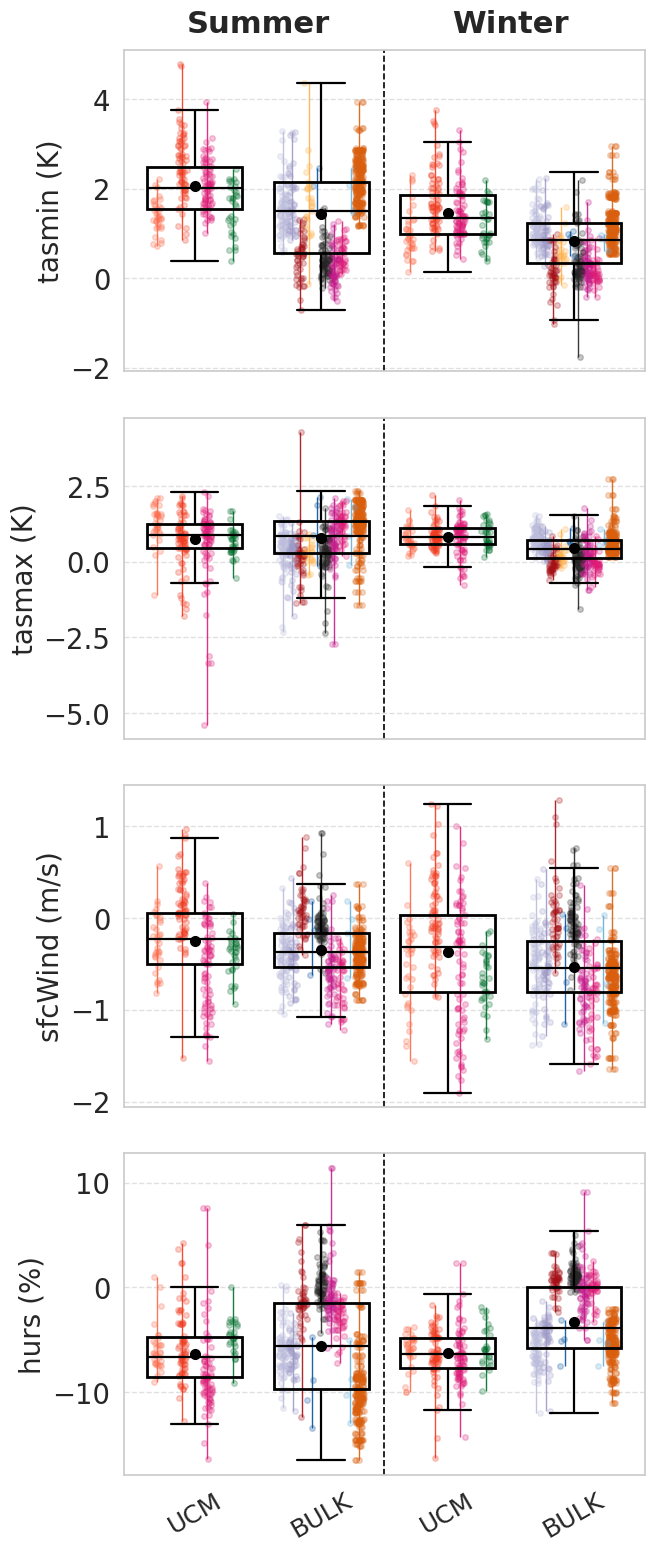

In [41]:
plot_boxplots_by_urban_scheme(
    records=records,
    models_plot=models_plot,
    model_color_map=model_color_map,
    period=period,
    save_summary_path=save_summary_path
)

## Analysis and Plots by AR6 Climate Region

This section details the analysis of climate projections based on the IPCC's AR6 (Sixth Assessment Report) reference regions, providing a standard geographical stratification for climate impact assessment.

### Classify each city

##### LOAD AR6 (IPCC) REGIONS


In [42]:
# Access the defined AR6 regions (all regions) from regionmask
ar6 = regionmask.defined_regions.ar6.all

# Extract region properties
region_polygons = ar6.polygons
region_names = ar6.names
region_abbrevs = ar6.abbrevs

# Create a GeoDataFrame for the AR6 regions using the extracted data
gdf_ar6 = gpd.GeoDataFrame(
    {"AR6_Region": region_names, "AR6_Code": region_abbrevs},
    geometry=region_polygons,
    crs="EPSG:4326" # AR6 regions are defined in WGS84
)

##### ENSURE CITY CENTROIDS AND COORDINATES

In [43]:
if gdf_europe.crs is None or "4326" not in str(gdf_europe.crs):
    gdf_europe = gdf_europe.to_crs("EPSG:4326")

# Calculate the centroid for each urban area geometry
gdf_europe["centroid"] = gdf_europe.geometry.centroid
# Extract Longitude (x-coordinate) and Latitude (y-coordinate) from the centroids
gdf_europe["lon"] = gdf_europe["centroid"].x
gdf_europe["lat"] = gdf_europe["centroid"].y

# Create a new GeoDataFrame containing only the city centroids as Point geometries
gdf_points = gpd.GeoDataFrame(
    gdf_europe.copy(), 
    geometry=gpd.points_from_xy(gdf_europe["lon"], gdf_europe["lat"]),
    crs="EPSG:4326"
)

/tmp/ipykernel_4098545/2151857991.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_europe["centroid"] = gdf_europe.geometry.centroid


##### SPATIAL JOIN WITH AR6 REGIONS

In [44]:
gdf_joined = gpd.sjoin(gdf_points, gdf_ar6, how="left", predicate="within")

print("Columns after spatial join:\n", gdf_joined.columns)

# Extract the correct AR6 region columns and assign them back to the original 'gdf_europe'

if "AR6_Code_right" in gdf_joined.columns:
    gdf_europe["AR6_Code"] = gdf_joined["AR6_Code_right"]
    gdf_europe["AR6_Region"] = gdf_joined["AR6_Region_right"]
else:
    # Handle the case where the suffixes were not applied (e.g., if columns only existed in the right table)
    gdf_europe["AR6_Code"] = gdf_joined.get("AR6_Code", np.nan)
    gdf_europe["AR6_Region"] = gdf_joined.get("AR6_Region", np.nan)

print("\nVerification of AR6 Region Assignment:")
print(gdf_europe[["GC_UCN_MAI_2025", "lon", "lat", "AR6_Code", "AR6_Region"]].head())

Columns after spatial join:
 Index(['ID_UC_G0', 'GC_UCN_MAI_2025', 'GC_UCN_LIS_2025', 'GC_CNT_GAD_2025',
       'GC_CNT_UNN_2025', 'GC_UCA_KM2_2025', 'GC_POP_TOT_2025',
       'GC_DEV_WIG_2025', 'GC_DEV_USR_2025', 'GC_PLS_SCR_2025',
       'GC_UCB_YOB_2025', 'GC_UCB_YOD_2025', 'GC_UCM_CAP', 'geometry_char',
       'geometry_centroid', 'is_coastal', 'elevation', 'is_mountain',
       'is_inland', 'city_type', 'centroid', 'lon', 'lat', 'geometry',
       'index_right', 'AR6_Region', 'AR6_Code'],
      dtype='object')

Verification of AR6 Region Assignment:
           GC_UCN_MAI_2025        lon        lat AR6_Code           AR6_Region
68                   Turin   7.652705  45.068640      WCE  West&Central-Europe
73              Gothenburg  11.971914  57.705204      NEU             N.Europe
107                  Sofia  23.323590  42.682506      MED        Mediterranean
227                 Lisbon  -9.217014  38.760458      MED        Mediterranean
240  Rotterdam [The Hague]   4.362934  51.98

### Load the data

In [45]:
# Map city names (GC_UCN_MAI_2025) to AR6 Region Codes
city_to_region = dict(zip(gdf_europe["GC_UCN_MAI_2025"], gdf_europe["AR6_Code"]))
df_box = pd.DataFrame(records).copy()

### Plot the boxplot

In [46]:
# =============================================================================
# AUTOMATIC UCM DETECTION FUNCTION
# =============================================================================
def get_model_style(model_name):
    """
    Returns plotting style for a given model.

    UCM-enabled models (identified by 'TEB' or 'UCM' in the name)
    are automatically assigned dashed linestyle.

    Parameters
    ----------
    model_name : str
        Full model identifier.

    Returns
    -------
    dict
        Dictionary containing linestyle and marker.
    """

    # Explicit definition takes priority
    if model_name in model_style_map:
        return model_style_map[model_name]

    # Automatic detection of UCM configurations
    if ("TEB" in model_name) or ("UCM" in model_name):
        return {"linestyle": "--", "marker": "o"}

    # Default style (non-UCM)
    return {"linestyle": "-", "marker": "o"}

In [47]:
def plot_boxplots_ar6_regions(
    df_box,
    city_to_region,
    model_color_map,
    period,
    save_summary_path
):
    """
    Generate faceted boxplots of climate variable anomalies grouped by
    AR6 region and season. The visualization includes:

    - Model min–max ranges (vertical lines)
    - Distribution boxplots across all cities
    - Individual model scatter points
    - Seasonal grouping of AR6 regions

    Parameters
    ----------
    df_box : pandas.DataFrame
        DataFrame containing the extracted seasonal statistics.
        Must include columns:
        ['City', 'Model', 'Variable', 'Season', 'Value'].

    city_to_region : dict
        Mapping between city names and AR6 region codes
        (e.g., {"Barcelona": "MED"}).

    model_color_map : dict
        Mapping between model base names and plotting colors.

    period : pandas.Interval or similar
        Time period used for labeling the output figure.

    save_summary_path : str
        Directory where the figure will be saved.

    Returns
    -------
    None
        Saves the generated figures (PNG and PDF).
    """
    if df_box.empty:
        print("df_box is empty; no data available for plotting.")
        return

    df_box = df_box.copy()

    # --------------------------------------------------
    # Assign AR6 region classification
    # --------------------------------------------------
    df_box["AR6_Code"] = df_box["City"].map(city_to_region)
    df_box = df_box.dropna(subset=["AR6_Code"])

    # --------------------------------------------------
    # Create Region–Season category
    # --------------------------------------------------
    df_box["Region_Season"] = (
        df_box["AR6_Code"]
        + " "
        + df_box["Season"].str.replace(r"\s\(.+\)", "", regex=True)
    )

    # --------------------------------------------------
    # Visualization settings
    # --------------------------------------------------
    sns.set(style="whitegrid", font_scale=1.8)

    region_order = ["MED", "WCE", "NEU"]
    seasons = ["Summer", "Winter"]

    type_season_order = [
        f"{region} {season}"
        for season in seasons
        for region in region_order
    ]

    n_per_season = len(region_order)

    # Region grayscale edge colors
    gray_levels = ["0.7", "0.5", "0.0"]
    region_color_map = dict(zip(region_order, gray_levels))

    variables = df_box["Variable"].unique()
    n_vars = len(variables)

    fig_width = 3 * n_per_season
    fig_height = 4.2 * n_vars

    fig, axes = plt.subplots(
        n_vars,
        1,
        figsize=(fig_width, fig_height),
        sharex=True
    )

    if n_vars == 1:
        axes = [axes]

    # --------------------------------------------------
    # Plotting loop
    # --------------------------------------------------
    for ax, variable in zip(axes, variables):

        data_plot = df_box[df_box["Variable"] == variable].copy()
        data_plot = data_plot[data_plot["Region_Season"].isin(type_season_order)]

        if data_plot.empty:
            continue

        # Model min–max ranges
        grouped = (
            data_plot
            .groupby(["Region_Season", "Model"])["Value"]
            .agg(["min", "max"])
            .reset_index()
        )

        model_xpos = {}

        for i, category in enumerate(type_season_order):

            subset = grouped[grouped["Region_Season"] == category]
            n_models = len(subset)

            if n_models == 0:
                continue

            offsets = np.linspace(-0.3, 0.3, n_models)

            for offset, (_, row) in zip(offsets, subset.iterrows()):

                model = row["Model"]
                model_base = model.split("_v")[0]

                color = model_color_map.get(model_base, "#999999")

                x_pos = i + offset
                model_xpos[(category, model)] = x_pos

                ax.vlines(
                    x=x_pos,
                    ymin=row["min"],
                    ymax=row["max"],
                    color=color,
                    linewidth=1,
                    alpha=0.9,
                    zorder=1
                )

        # Boxplots
        sns.boxplot(
            data=data_plot,
            x="Region_Season",
            y="Value",
            order=type_season_order,
            ax=ax,
            width=0.75,
            showfliers=False,
            showmeans=True,
            meanprops={
                "marker": "o",
                "markerfacecolor": "black",
                "markeredgecolor": "black",
                "markersize": 7
            },
            palette=["white"] * len(type_season_order),
            linewidth=1.6,
            zorder=20
        )

        # Style boxplots
        for patch in ax.patches:
            patch.set_facecolor("none")
            patch.set_edgecolor("black")
            patch.set_linewidth(2.0)
            patch.set_zorder(20)

        for line in ax.lines:
            line.set_color("black")
            line.set_linewidth(1.6)
            line.set_zorder(21)

        # Model scatter points
        jitter_amplitude = 0.035

        for _, row in data_plot.iterrows():

            category = row["Region_Season"]
            model = row["Model"]

            base_x = model_xpos.get((category, model))
            if base_x is None:
                continue

            jitter = (np.random.rand() - 0.5) * 2 * jitter_amplitude
            x_pos = base_x + jitter

            model_base = model.split("_v")[0]
            color = model_color_map.get(model_base, "#999999")

            ax.plot(
                x_pos,
                row["Value"],
                "o",
                color=color,
                alpha=0.25,
                markersize=4,
                zorder=10
            )

        # Season separator
        ax.axvline(
            n_per_season - 0.5,
            color="black",
            linestyle="--",
            lw=1.2
        )

        # Axis formatting
        ax.set_xticks(range(len(type_season_order)))
        ax.set_xticklabels(region_order * 2, fontsize=18, rotation=30)

        ax.set_xlabel("")

        units = {
            "tasmin": "K",
            "tasmax": "K",
            "pr": "% (mm/day)",
            "sfcWind": "m/s",
            "hurs": "%"
        }.get(variable, "")

        ax.set_ylabel(f"{variable} ({units})", fontsize=20)
        ax.grid(True, axis="y", linestyle="--", alpha=0.6)

    # --------------------------------------------------
    # Season labels
    # --------------------------------------------------
    top_ax = axes[0]

    ylim = top_ax.get_ylim()

    summer_center = (0 + (n_per_season - 1)) / 2
    winter_center = summer_center + n_per_season

    top_ax.text(
        summer_center,
        ylim[1] * 1.05,
        "Summer",
        ha="center",
        va="bottom",
        fontsize=22,
        fontweight="bold"
    )

    top_ax.text(
        winter_center,
        ylim[1] * 1.05,
        "Winter",
        ha="center",
        va="bottom",
        fontsize=22,
        fontweight="bold"
    )

    # --------------------------------------------------
    # Save figure
    # --------------------------------------------------
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    filename_base = f"CMIP6_Boxplot_AR6_AllVariables_{period.left}-{period.right}"

    output_png_path = os.path.join(save_summary_path, filename_base + ".png")
    output_pdf_path = os.path.join(save_summary_path, filename_base + ".pdf")

    fig.savefig(output_png_path, dpi=400, bbox_inches="tight")
    fig.savefig(output_pdf_path, dpi=400, bbox_inches="tight")

    print("Figure saved:", output_png_path)
    print("Figure saved:", output_pdf_path)

    plt.show()

/tmp/ipykernel_4098545/3783729100.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4098545/3783729100.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4098545/3783729100.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4098545/3783729100.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Figure saved: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Boxplot_AR6_AllVariables_1991-2020.png
Figure saved: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Boxplot_AR6_AllVariables_1991-2020.pdf


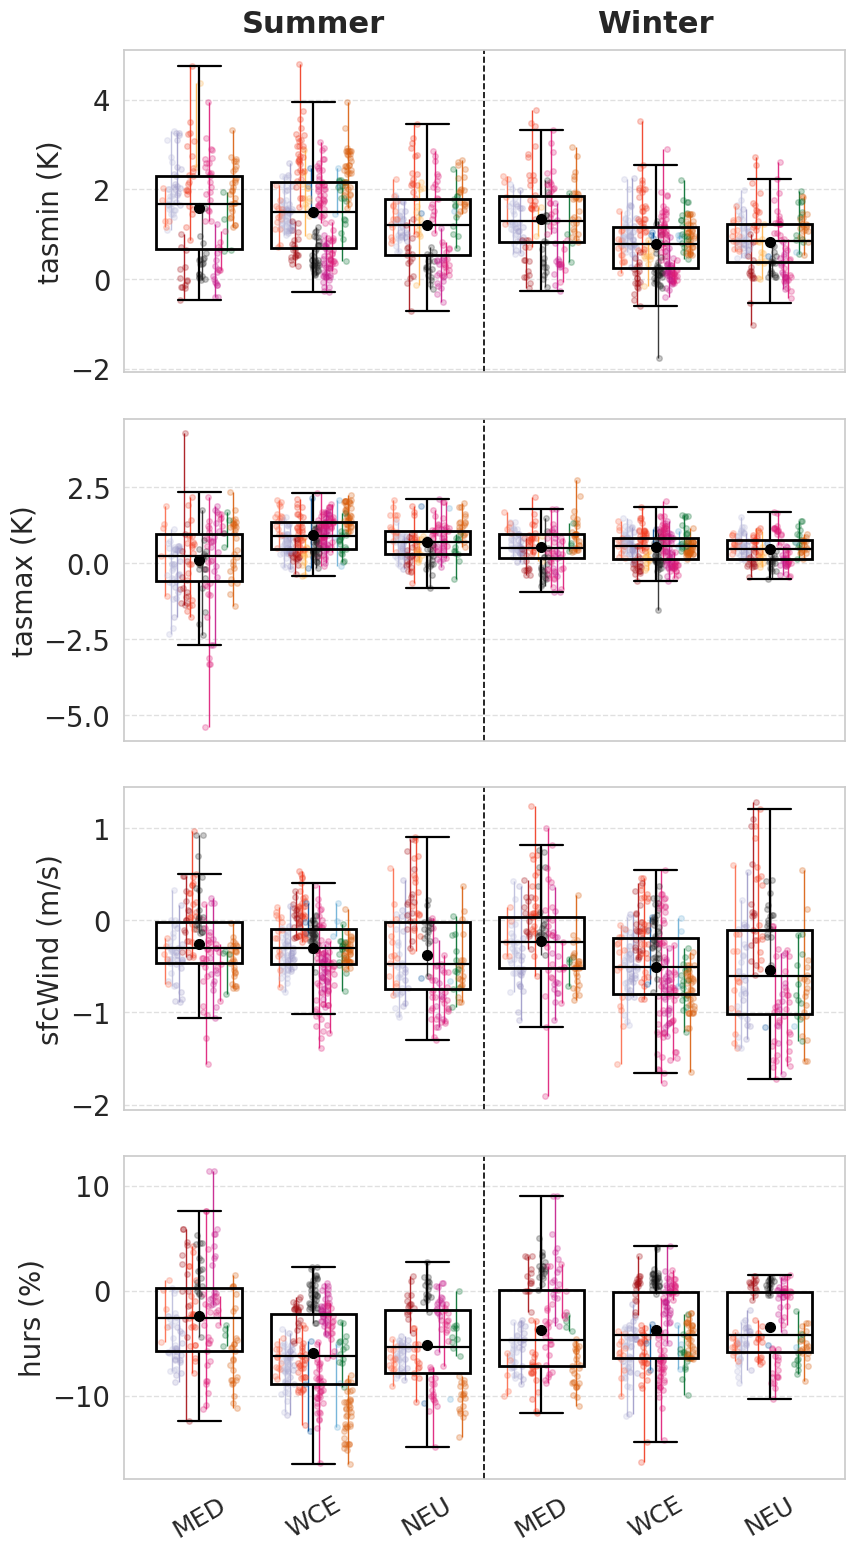

In [48]:
plot_boxplots_ar6_regions(
    df_box=df_box,
    city_to_region=city_to_region,
    model_color_map=model_color_map,
    period=period,
    save_summary_path=save_summary_path
)

### Manually make the legend

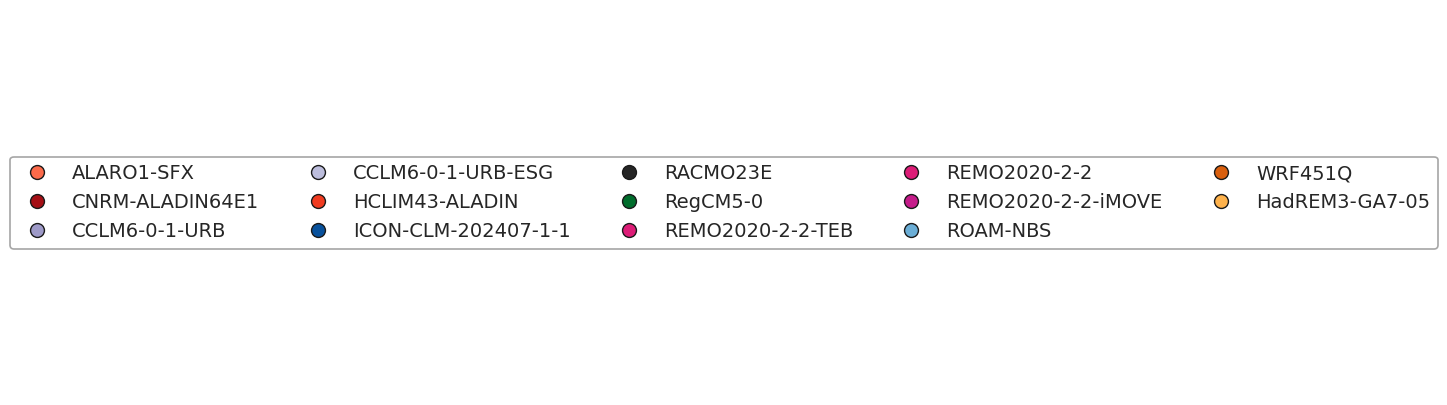

Figure saved: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/Legend_1991-2020.png
Figure saved: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/Legend_1991-2020.pdf


In [49]:
# =============================================================================
# CREATE LEGEND ELEMENTS FOR EACH MODEL
# =============================================================================
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=m.split("_v")[0], 
        # Asegúrate de que model_color_map y rcm_names estén definidos previamente
        markerfacecolor=model_color_map.get(m.split("_v")[0], "#999999"), 
        markeredgecolor='k', 
        markersize=10
    )
    for m in rcm_names 
]

# =============================================================================
# GENERATE AND DISPLAY STANDALONE LEGEND FIGURE
# =============================================================================
fig_leg = plt.figure(figsize=(6, 5))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis("off")

legend = ax_leg.legend(
    handles=legend_elements,
    loc="center",
    fontsize=14,
    title_fontsize=16,
    ncol=5, 
    frameon=True 
)

frame = legend.get_frame()
frame.set_facecolor("white")
frame.set_alpha(0.7)
frame.set_edgecolor("gray")
frame.set_linewidth(1.2)

# =============================================================================
# SAVE AND DISPLAY
# =============================================================================

filename_base = f"Legend_{period.left}-{period.right}"

output_png_path = os.path.join(save_summary_path, filename_base + ".png")
output_pdf_path = os.path.join(save_summary_path, filename_base + ".pdf")

fig_leg.savefig(
    output_png_path,
    dpi=400,
    bbox_inches="tight"
)

fig_leg.savefig(
    output_pdf_path,
    dpi=400,
    bbox_inches="tight"
)

plt.show() 
plt.close(fig_leg) 

print("Figure saved:", output_png_path)
print("Figure saved:", output_pdf_path)